In [6]:
%matplotlib widget
from lines import REDUC_LINES
from corr import REDSHIFT, SPECTRALDATA
import numpy as np
import matplotlib.pyplot as plt
from lmfit.models import GaussianModel, PolynomialModel
from lmfit.parameter import Parameter
import pandas as pd
import os
from GaussianFitting import fitSpectrum
import astropy.constants as const
import seaborn as sns

A =  2.6352974994653753  +/-  0.1481032415834221
A S/N =  17.79365172085711
EW_rest =  3.8528123142728505  +/-  0.21035786861227104
EW_rest S/N=  18.31551317614035


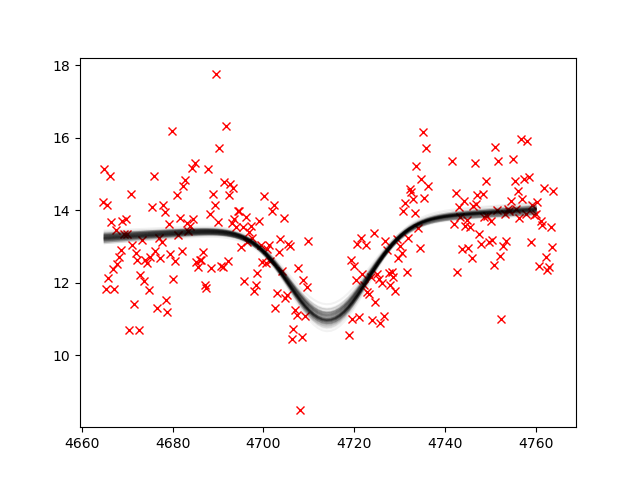

In [7]:
import csv

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

np.random.seed(1231)

stamp_fname = "/Users/javieratoro/Desktop/thesis/proyecto 2024-2/codes/h_gm.csv"


def read_file(fname):
    with open(fname, mode="r") as file:
        reader = csv.DictReader(file)
        for row in reader:
            wave = row["wave"]
            flux = row["flux"]
            f_err = row["err"]
            z = row["z"]
            w_center = row["w_center"]

    wave = np.array([float(el) for el in wave[1:-1].split()])
    flux = np.array([float(el) for el in flux[1:-1].split()])
    f_err = np.array([float(el) for el in f_err[1:-1].split()])
    z = float(z)
    w_center = float(w_center)
    return wave, flux, f_err, z, w_center


wave, flux, f_err, z, w_center = read_file(stamp_fname)

z = 0.08582889699531437

mu = w_center * (1 + z)
sigma = w_center * (1 + z) * 550 / 3e5

mask = np.isfinite(flux) & ((wave < mu - 0.5*sigma) | (wave > mu + 0.5*sigma))


def absorption(w, A, m, n):
    output = -A * np.exp(-((mu - w) ** 2) / (2 * sigma**2)) + m * w + n
    return output


#  Test one fit
p0 = 5.0, 0.0, 5.0
popt, pcov = curve_fit(absorption, wave[mask], flux[mask], p0)
# print(popt)

#
# Do a MC
#
N_mc = 100
f_mc = np.random.normal(loc=flux[mask], scale=f_err[mask], size=(N_mc, mask.sum()))
popt_mc = np.zeros((N_mc, 3))
for i in range(N_mc):
    popt, pcov = curve_fit(absorption, wave[mask], f_mc[i], p0)
    popt_mc[i] = popt

A_mean = np.mean(popt_mc[:, 0])
A_err = np.std(popt_mc[:, 0])
print("A = ", A_mean, " +/- ", A_err)
print("A S/N = ", A_mean / A_err)

EW_mc = (
    (popt_mc[:, 0] * np.sqrt(2 * np.pi * sigma**2))
    / (popt_mc[:, 1] * w_center * (1 + z) + popt_mc[:, 2])
    / (1 + z)
)
print("EW_rest = ", np.mean(EW_mc), " +/- ", np.std(EW_mc))
print("EW_rest S/N= ", np.mean(EW_mc) / np.std(EW_mc))


wave_to_plot = np.linspace(4665, 4760, 100)

plt.figure(1)
plt.clf()

# plt.plot(wave, flux, drawstyle="steps-mid")
plt.plot(wave[mask], flux[mask], "rx")
# for i in range(N_mc):
#     plt.plot(wave[mask], f_mc[i], "g.")

# plt.plot(wave_to_plot, absorption(wave_to_plot, *p0))
# plt.plot(wave_to_plot, absorption(wave_to_plot, *popt))
for i in range(N_mc):
    plt.plot(wave_to_plot, absorption(wave_to_plot, *popt_mc[i]), "k-", alpha=0.05)


plt.show()

In [8]:
mu = w_center * (1 + z)
sigma = w_center * (1 + z) * 550 / 3e5

def neg_gauss_(w, A):
    output = -A * np.exp(-((mu - w) ** 2) / (2 * sigma**2))
    return output

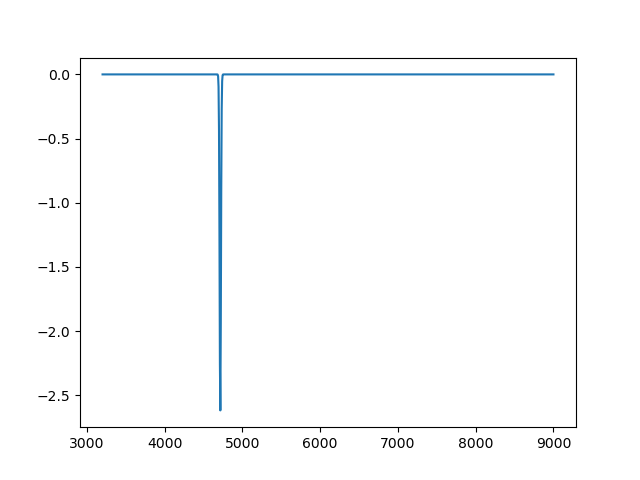

In [9]:
wave_to_plot = np.linspace(3200, 9000, 1000)
neg_gauss = neg_gauss_(wave_to_plot, A_mean)

plt.figure()
plt.plot(wave_to_plot, neg_gauss)
plt.show()

In [10]:
sigma

8.642922943428795

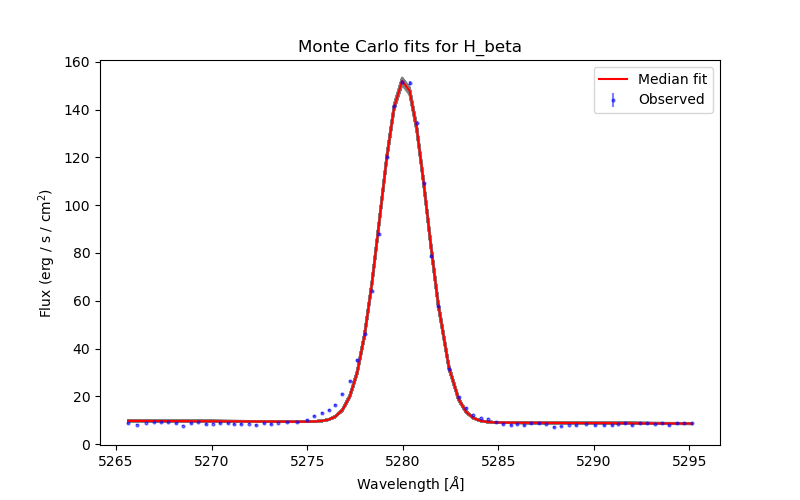

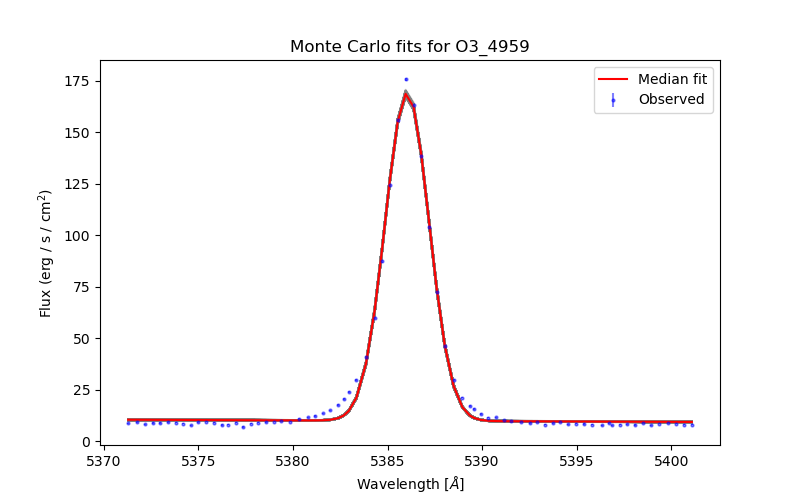

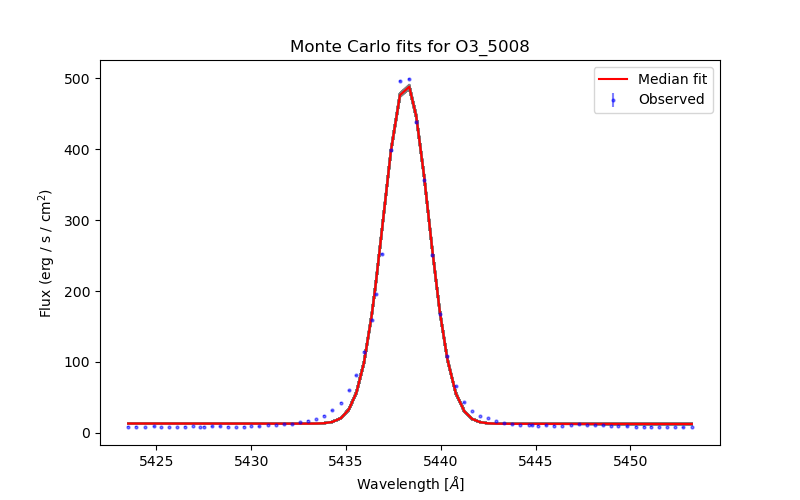

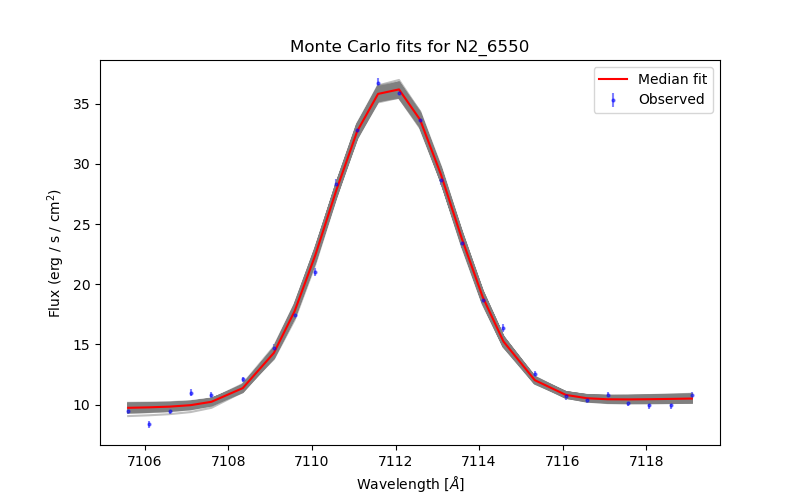

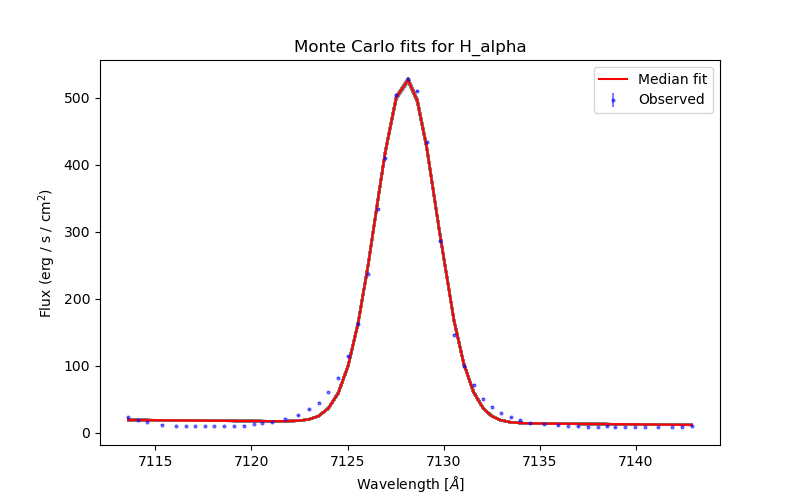

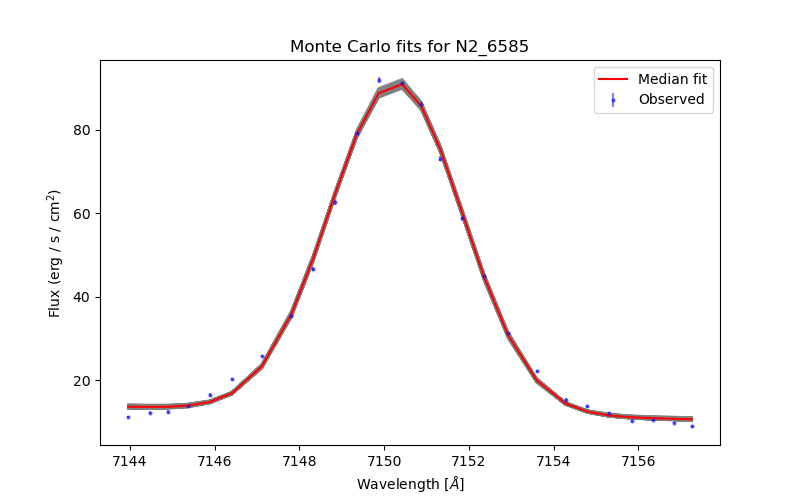

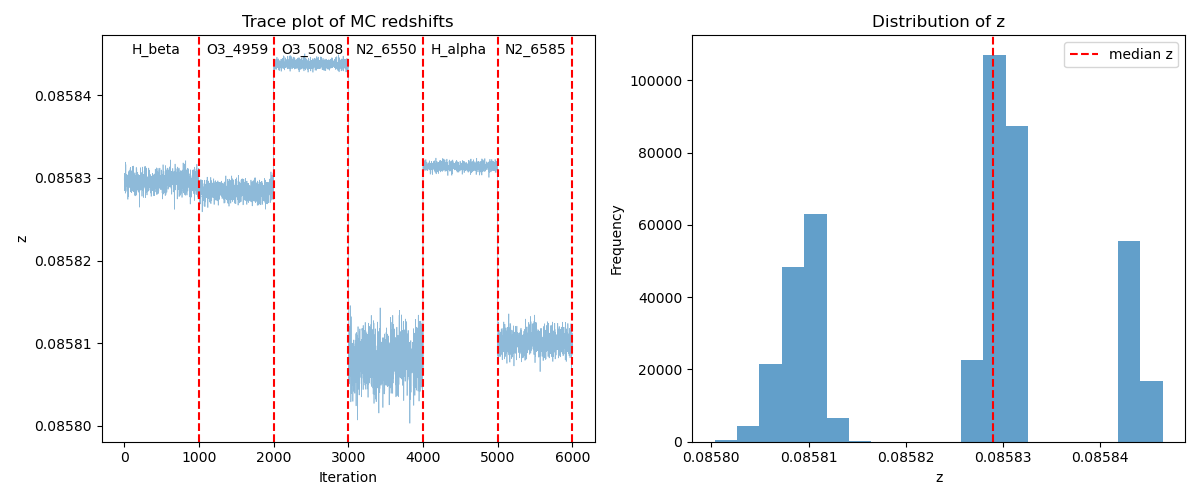

New redshift calculated for no_very_flats,z = 0.08582897071361717
Executed reset_redshift in 39.7056s
New redshift for J0328+0031,z = 0.08582897071361717


In [11]:
J0328_SPECTRA= {
    'DIR':'/Users/javieratoro/Desktop/thesis/BAADE_DATA/testing/35-J0328/',
    'FILES': ['no_very_flats/J0328_NO_VERY_FLATS_tellcorr.fits'],# 'twilight/J0243_TWILIGHT_tellcorr.fits'],
     'redshift': 0.086,
     'names':['J0328+0031'],
     'mass':9.8
}
J0328 = SPECTRALDATA(J0328_SPECTRA)
Z = REDSHIFT(J0328)

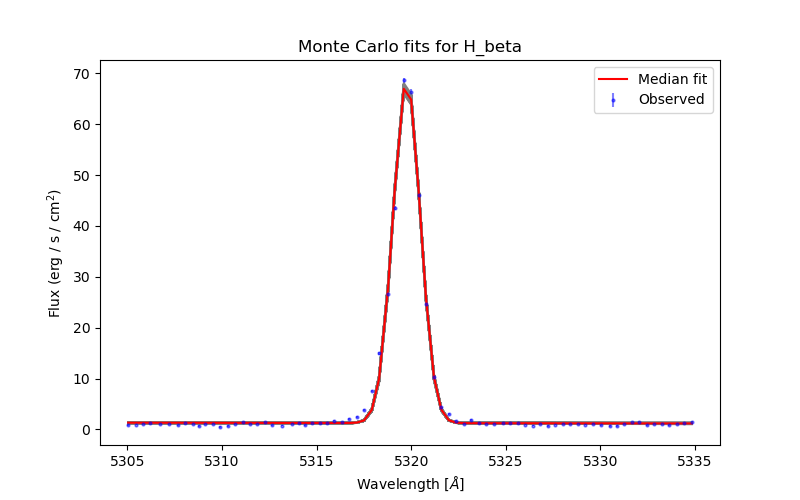

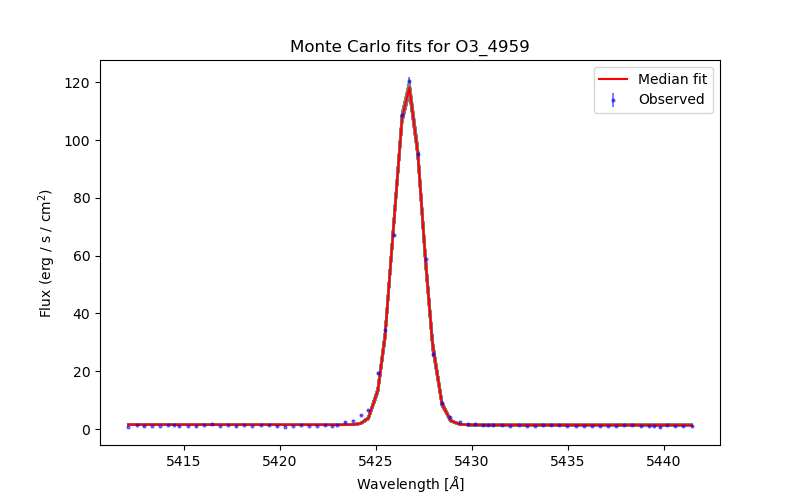

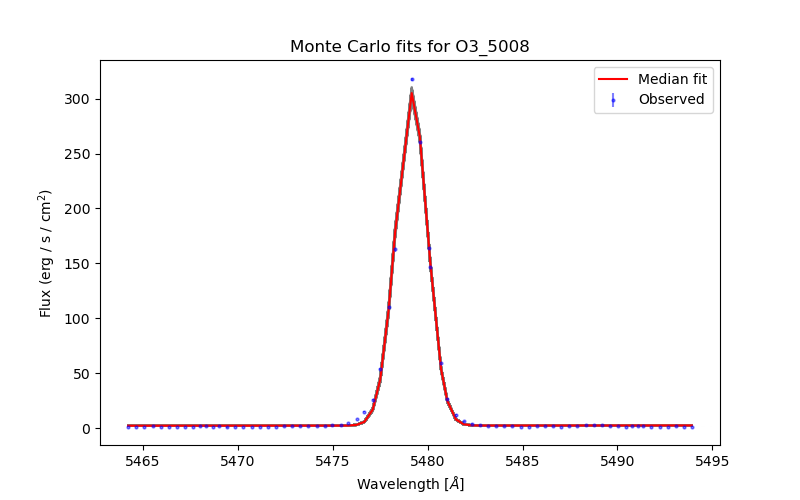

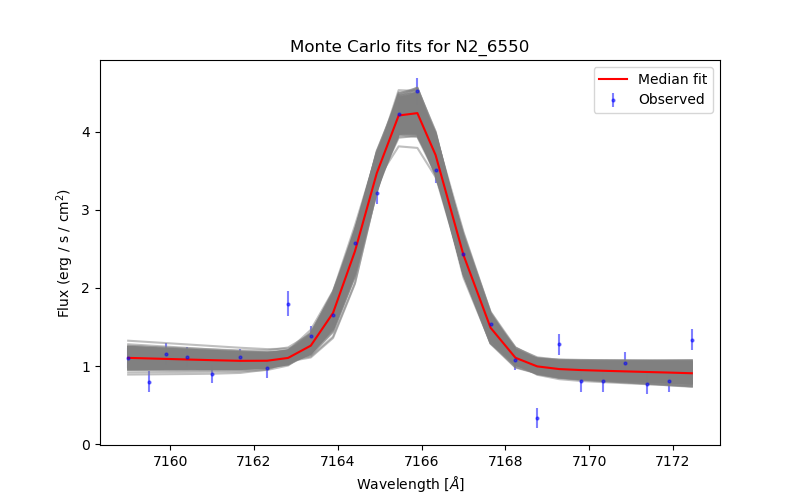

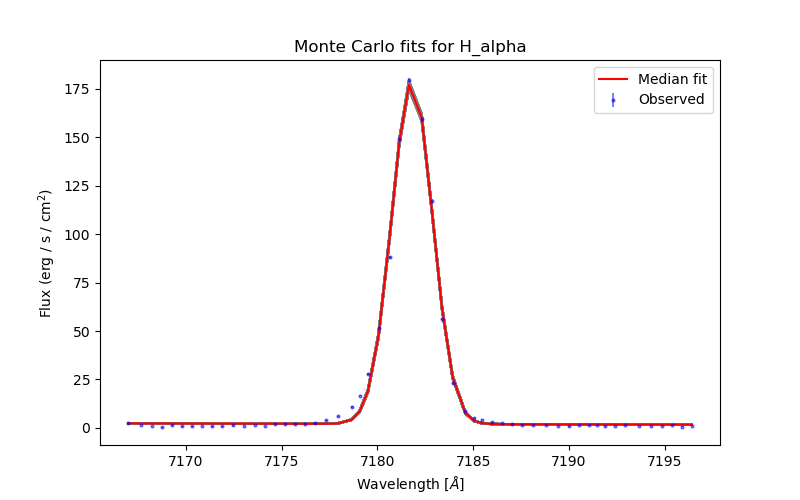

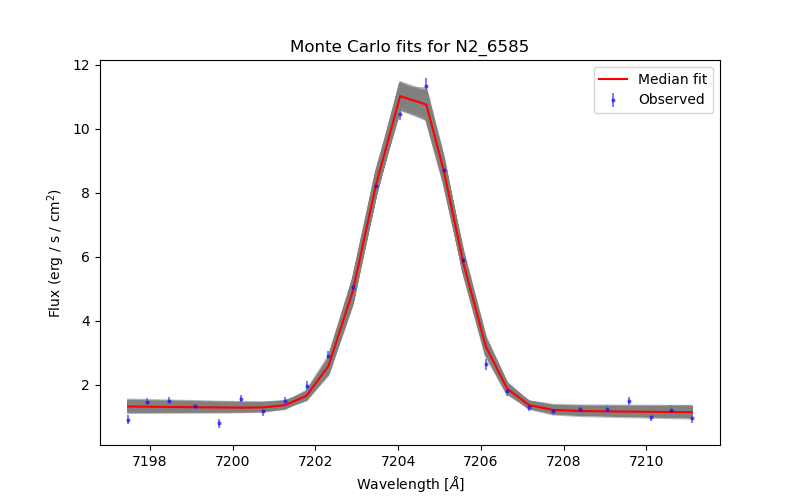

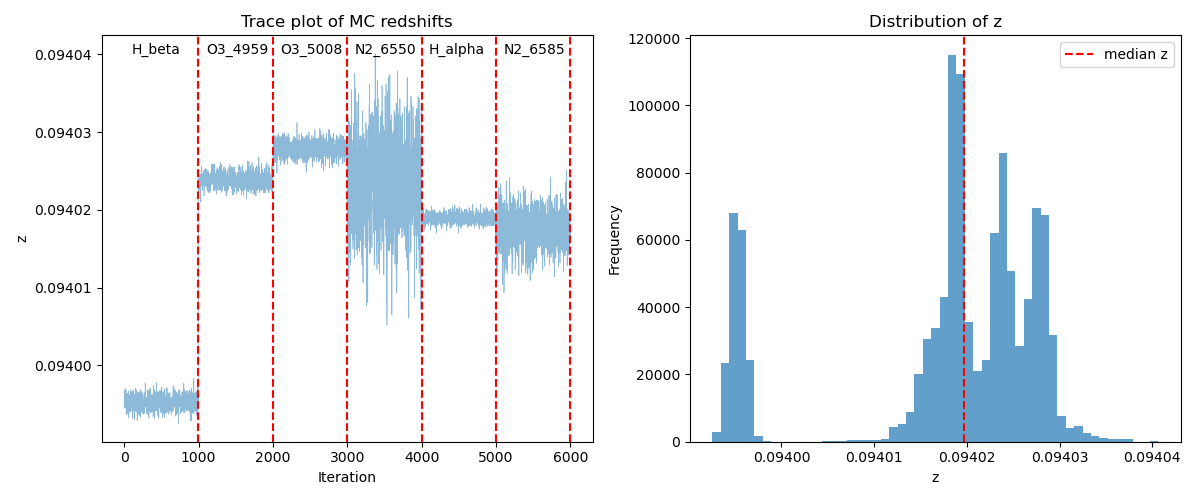

New redshift calculated for twilight,z = 0.09401968911430514
Executed reset_redshift in 38.0031s
New redshift for J2258+0056,z = 0.09401968911430514


In [12]:
J2258_SPECTRA= {
    'DIR':'/Users/javieratoro/Desktop/thesis/BAADE_DATA/testing/6-J2258/',
    'FILES': ['twilight/J2258_TWILIGHT_tellcorr.fits'], #'no_very_flats/J2258_NO_VERY_FLATS_tellcorr.fits'],
     'redshift': 0.094,
     'names':['J2258+0056'],
     'mass':9.6
}
J2258 = SPECTRALDATA(J2258_SPECTRA)
Z = REDSHIFT(J2258)

Reading data for J0328
Using MW dust + Balmer abs corrected and continuum substracted data


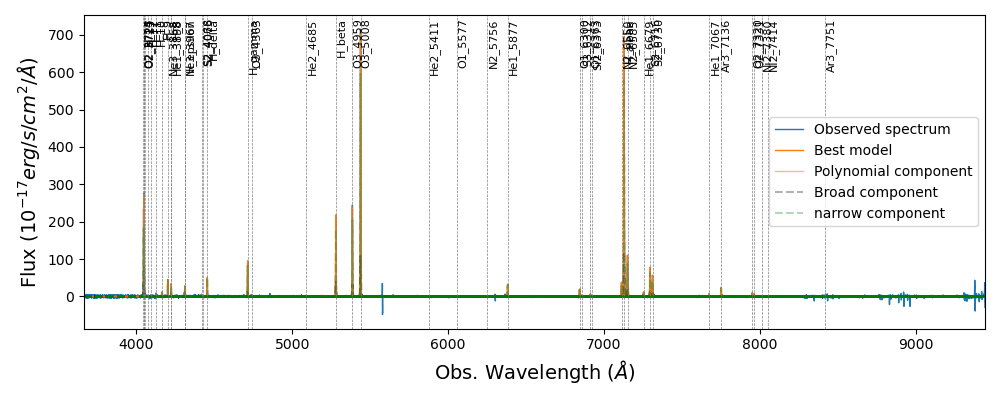

In [13]:
red = REDUC_LINES(J0328)
fit_all = red.fit_spectra(show_Plot=True)

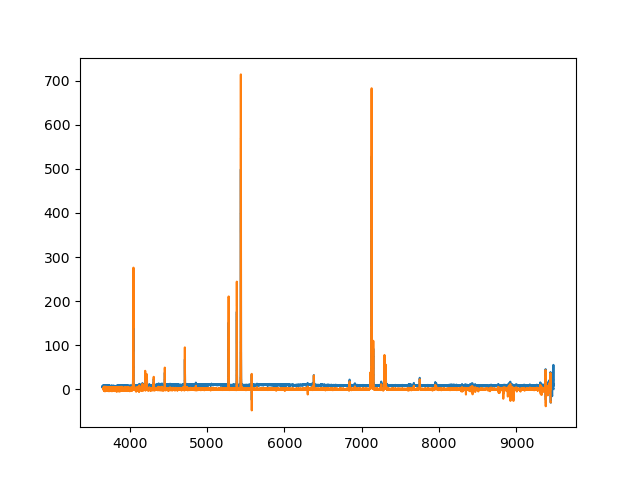

In [16]:
plt.figure()
plt.step(J0328.datas[0][0], J0328.datas[0][1])
plt.step(red.wave, red.flux)
plt.show()

## fiting line


/var/folders/b3/z1vmt1t542ncmpppx7tfrqd80000gn/T/ipykernel_6647/994777261.py:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axs = plt.subplots(1, 1, figsize=(8, 4))


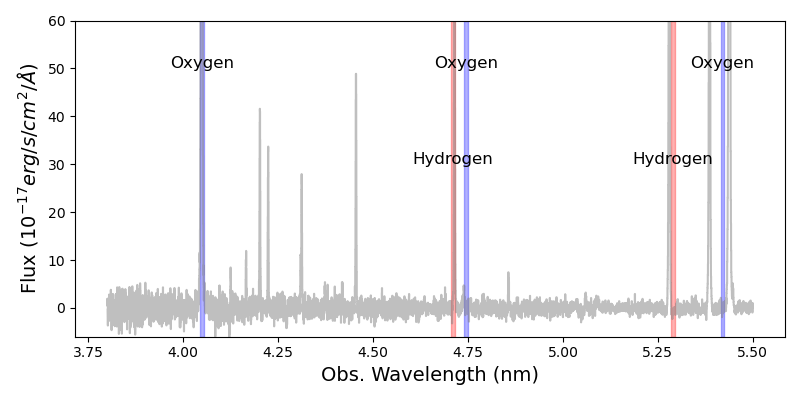

In [17]:
fig, axs = plt.subplots(1, 1, figsize=(8, 4))
axs.step(red.wave[(red.wave < 5500) & (red.wave > 3800)]/1000, red.flux[(red.wave < 5500) & (red.wave > 3800)], where='mid', label='spectrum', color='grey', alpha=0.5)

axs.text(4050/1000, 50, 'Oxygen', rotation=0, ha='center',
        color='k', size=12)
axs.axvspan(4050/1000 -0.005, 4050/1000 + 0.005, color='blue', alpha=0.3)


axs.text(5420/1000, 50, 'Oxygen', rotation=0, ha='center',
        color='k', size=12)
axs.axvspan(5420/1000 -0.005, 5420/1000 + 0.005, color='blue', alpha=0.3)


axs.text(4745/1000, 50, 'Oxygen', rotation=0, ha='center',
        color='k', size=12)
axs.axvspan(4745/1000 -0.005, 4745/1000 + 0.005, color='blue', alpha=0.3)

axs.text(5290/1000, 30, 'Hydrogen', rotation=0, ha='center',
        color='k', size=12)
axs.axvspan(5290/1000 -0.005, 5290/1000 + 0.005, color='red', alpha=0.3)

axs.text(4710/1000, 30, 'Hydrogen', rotation=0, ha='center',
        color='k', size=12)
axs.axvspan(4710/1000 -0.005, 4710/1000 + 0.005, color='red', alpha=0.3)

axs.set_ylim(-6, 60)
axs.set_xlabel(r'Obs. Wavelength (nm)', size=14)
axs.set_ylabel(r'Flux ($10^{-17} erg/s/cm^{2}/\AA$)', size=14)
plt.tight_layout()
plt.show()

In [18]:
def fitting_lines(lams, flux, linelist, z_init=0,
                  params=None, nfev=1000, fit=None,
                  A_ratio=None, plot=False):
    lams = np.asarray(lams)
    flux = np.asarray(flux)

    narrow_gaussians = []
    broad_gaussians  = []

    for label in linelist.keys():
        narrow_gaussians.append(GaussianModel(prefix=f'{label}_narrow_'))
        broad_gaussians.append(GaussianModel(prefix=f'{label}_broad_'))

    polydeg = 7
    polynomial = PolynomialModel(degree=polydeg)

    model = narrow_gaussians[0] + broad_gaussians[0]
    for n,b in zip(narrow_gaussians[1:], broad_gaussians[1:]):
        model += n + b

    model += polynomial

    pars = model.make_params()

    if params is None:
        pars.add('z', value=z_init, vary=True,
                 min=z_init-1e-4, max=z_init+1e-4)

        for label in linelist:
            lam0 = linelist[label]

            if fit is not None:
                sigma_v_nar = fit.params['sigma_v_narrow'].value
                sigma_v_bro = fit.params['sigma_v_broad'].value
                pars.add('sigma_v_narrow', value=sigma_v_nar, vary=False)
                pars.add('sigma_v_broad', value=sigma_v_bro, vary=False)

            else:
                pars.add('sigma_v_narrow', value=50, min=20, max=70)
                pars.add('sigma_v_broad', value=90, min=70, max=500)

                pars.add(f'{label}_broad_amplitude', value=0.3, vary=True, min=0.0)

            if A_ratio is not None:
                ratio_median = np.median(A_ratio)
                pars.add('ratio', value=ratio_median, vary=False)
                pars.add(f'{label}_broad_amplitude', vary=True,
                            expr=f'ratio*{label}_narrow_amplitude*(sigma_v_broad/sigma_v_narrow)')

            pars.add(f'{label}_narrow_center',
                    value=lam0, vary=False,
                    expr=f'{lam0}*(1+z)')

            pars.add(f'{label}_narrow_amplitude',
                    value=50, vary=True, min=0.0)

            pars.add(f'{label}_narrow_sigma',
                    vary=False,
                    expr=f'(sigma_v_narrow/3e5)*{label}_narrow_center',
                    min=0)

            pars.add(f'{label}_broad_center',
                        value=lam0, vary=False,
                        expr=f'{lam0}*(1+z)')

            pars.add(f'{label}_broad_sigma',
                        vary=False,
                        expr=f'(sigma_v_broad/3e5)*{label}_broad_center',
                        min=0)

        for i in range(polydeg+1):
            pars[f'c{i}'].set(value=0.0, vary=False)


    else:
        pars = params

    out = model.fit(flux, pars, x=lams,
                    nan_policy='omit',
                    max_nfev=nfev)
    if plot:
        plotting_fit(lams, flux, out, linelist)
    return out

def plotting_fit(lams, flux, out, linelist):
    fig2, ax = plt.subplots(figsize=(10, 4))
    comps = out.eval_components(x=lams)

    ax.plot(lams, flux, lw=1, drawstyle='steps-mid', label='Observed spectrum')
    ax.plot(lams, out.best_fit, lw=1, drawstyle='steps-mid',
            label='Best model')
    ax.plot(lams, comps['polynomial'], 'r-', label='Polynomial component',
            lw=1, drawstyle='steps-mid', alpha=0.3)

    broad_key = [key for key, _ in comps.items() if 'broad' in key]
    narrow_key = [key for key, _ in comps.items() if 'narrow' in key]

    for i, broad_line in enumerate(broad_key):
        if i == len(broad_key) - 1:
            ax.plot(lams, comps[broad_line] + comps['polynomial'], 'k--',
                    label='Broad component', alpha=0.3)
        else:
            ax.plot(lams, comps[broad_line] + comps['polynomial'], 'k--',
                    alpha=0.3)

    for i, narrow_line in enumerate(narrow_key):
        if i == len(narrow_key) - 1:
            ax.plot(lams, comps[narrow_line] + comps['polynomial'], 'g--',
                    label='narrow component', alpha=0.3)
        else:
            ax.plot(lams, comps[narrow_line] + comps['polynomial'], 'g--',
                    alpha=0.3)

    for label in linelist.keys():
        z = out.params['z'].value
        obs_lam = linelist[label] * (1+z)
        ax.axvline(obs_lam, linestyle='--', linewidth=1, color='grey', lw=0.5)
        ax.text(obs_lam, 0.99, '\n'+label, rotation=90, ha='center', va='top',
                color='k', size=8, transform=ax.get_xaxis_transform())

    ax.set_xlabel(r'Obs. Wavelength ($\AA$)', size=14)
    ax.set_ylabel(r'Flux ($10^{-17} erg/s/cm^{2}/\AA$)', size=14)
    ax.set_xlim([np.min(lams), np.max(lams)])
    ax.legend()
    fig2.tight_layout()
    plt.show()

def a_ratio_dist(out, plot=False):
    ratios = []
    for label in out.params.keys():
        if 'narrow_height' in label:
            broad_label = label.replace('narrow', 'broad')
            ratio = out.params[broad_label].value / out.params[label].value
            ratios.append(ratio)
    ratios = np.array(ratios)
    ratios = ratios[(ratios>9e-2) & (ratios<1)]
    if plot:
        plt.figure()
        sns.boxplot(data=ratios, width=0.3)
        sns.stripplot(data=ratios, color='black', size=8, jitter=True, alpha=0.7)
        plt.title("Narrow to broad Amplitude Ratios")
        plt.ylabel("Value")
        plt.show()
    return ratios

In [19]:
linelist = red.spectra.linelist_dict
bright_lines = ['H_14', 'H_13', 'O2_3725', 'O2_3727', 'H_alpha', 'H_beta',
                'O3_5008', 'O3_4959', 'N2_6550', 'N2_6585',
                'S2_6716','S2_6730']

bright_dict = {k: v for k, v in linelist.items() if k in bright_lines}
faint_dict  = {k: v for k, v in linelist.items() if k not in bright_lines}

# mask = (red.wave < 4500*(1+red.spectra.redshift))
# wave1, flux1, sigma1 = red.wave[mask], red.flux[mask], red.sigma[mask]
# wave2, flux2, sigma2 = red.wave[~mask], red.flux[~mask], red.sigma[~mask]

# blue_lines_b = {k:v for k,v in bright_dict.items() if v < 4500}
# red_lines_b  = {k:v for k,v in bright_dict.items() if v >= 4500}

# blue_lines_f = {k:v for k,v in faint_dict.items() if v < 4500}
# red_lines_f  = {k:v for k,v in faint_dict.items() if v >= 4500}

# lines = red.spectra.linelist_dict
# blue_lines = {k:v for k,v in lines.items() if v < 4500}
# red_lines = {k:v for k,v in lines.items() if v >= 4500}

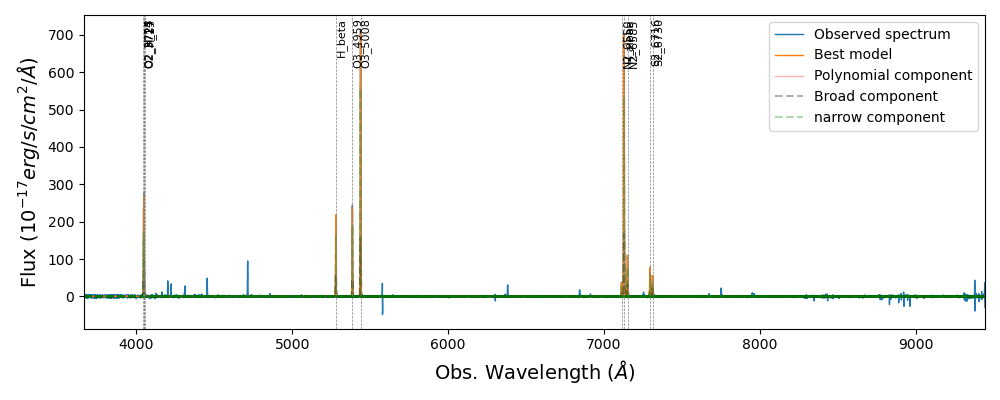

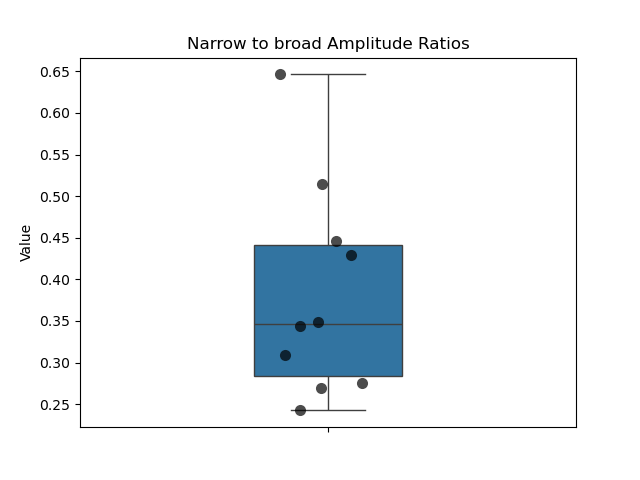

In [20]:
init = fitting_lines(red.wave, red.flux,
                     bright_dict,
                     z_init=red.spectra.redshift, plot=True,
                     nfev=1000, fit=None, A_ratio=None)
ratios = a_ratio_dist(init, plot=True)

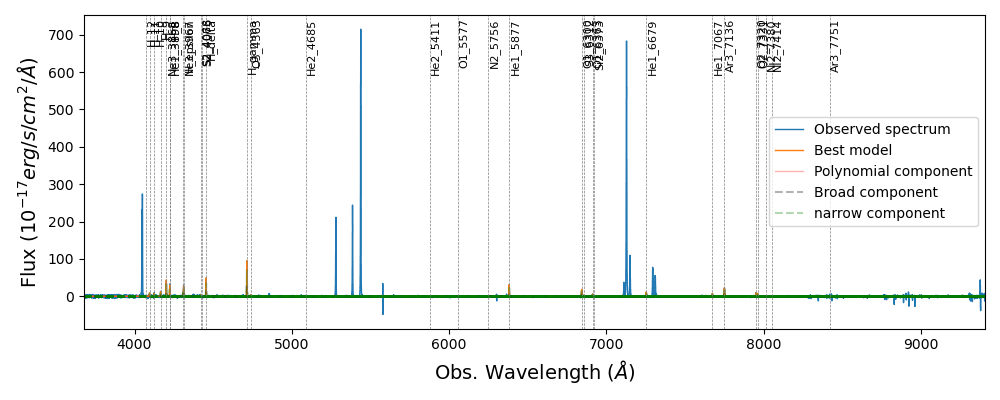

In [7]:
faint = fitting_lines(red.wave, red.flux,
                     faint_dict,
                     z_init=red.spectra.redshift, plot=True,
                     nfev=1000, fit=None, A_ratio=ratios)

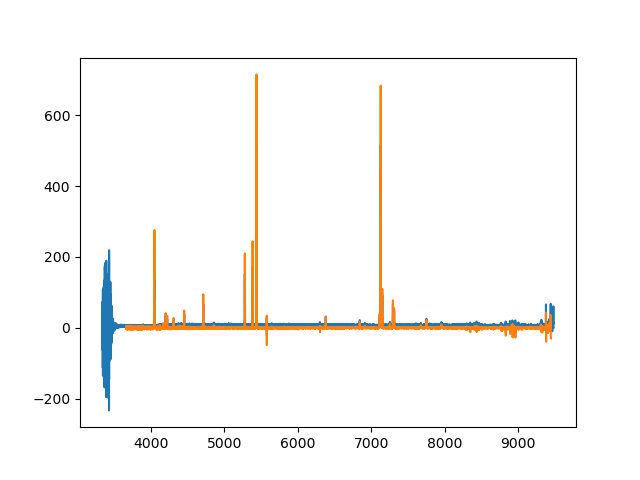

In [55]:
import pandas as pd
from astropy.io import fits

path = '/Users/javieratoro/Desktop/thesis/BAADE_DATA/testing/35-J0328/twilight/J0328_TWILIGHT_tellcorr.fits'
hdu = fits.open(path)
data = hdu[1].data

corr = pd.read_csv('/Users/javieratoro/Desktop/thesis/proyecto 2024-2/cont_subs/J0328/cont_corr_J0328_new.csv')
plt.figure()
plt.step(data['wave'], data['flux'])
plt.step(corr['wave'], corr['flux'])
plt.show()

In [50]:
hdu[1].data


FITS_rec([(3343.71862829, 3343.844363  , -0.        , 0.        , 0.        , 0, 0.        , 0.        ),
          (3343.9909884 , 3344.09705045,  8.89923348, 0.01450932, 8.30187958, 1, 0.98468005, 1.22068855),
          (3344.26353721, 3344.34975698, -9.32001027, 0.01618154, 7.86122141, 1, 0.98519793, 1.22072988),
          ...,
          (9476.24106348, 9476.2237323 ,  1.35091863, 0.73991316, 1.1625446 , 1, 0.69434285, 0.71326904),
          (9476.8245275 , 9476.93983104, -0.0246278 , 0.37395415, 1.63527509, 1, 0.66570142, 0.71322485),
          (9477.44337208, 9477.65598389, -0.        , 0.        , 0.        , 0, 0.        , 0.        )],
         dtype=(numpy.record, [('wave', '>f8'), ('wave_grid_mid', '>f8'), ('flux', '>f8'), ('ivar', '>f8'), ('sigma', '>f8'), ('mask', '>i8'), ('telluric', '>f8'), ('obj_model', '>f8')]))

In [30]:
def fit_lines(class_):
    linelist = class_.spectra.linelist_dict
    bright_lines = ['H_14', 'H_13', 'O2_3725', 'O2_3727', 'H_alpha', 'H_beta',
                    'O3_5008', 'O3_4959', 'N2_6550', 'N2_6585',
                    'S2_6716','S2_6730']

    bright_dict = {k: v for k, v in linelist.items() if k in bright_lines}
    faint_dict  = {k: v for k, v in linelist.items() if k not in bright_lines}

    bright = fitting_lines(class_.wave, class_.flux,
                     bright_dict,
                     z_init=class_.spectra.redshift, plot=True,
                     nfev=1000, fit=None, A_ratio=None)
    ratios = a_ratio_dist(bright, plot=False)

    faint = fitting_lines(class_.wave, class_.flux,
                     faint_dict,
                     z_init=class_.spectra.redshift, plot=True,
                     nfev=1000, fit=None, A_ratio=ratios)   
    
    

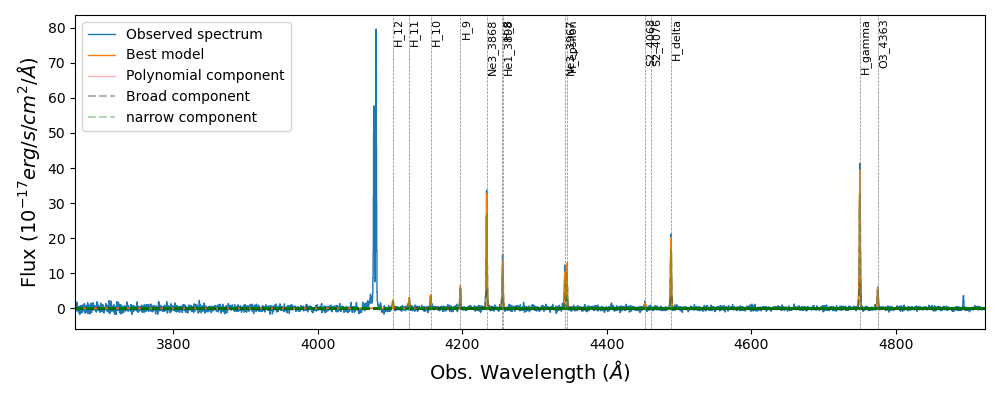

In [15]:
out_blue = fitting_lines(wave1, flux1,
                    blue_lines_f,
                    z_init=red.spectra.redshift, plot=True,
                    nfev=1000, fit=init, A_ratio=ratios)

In [17]:
out_blue

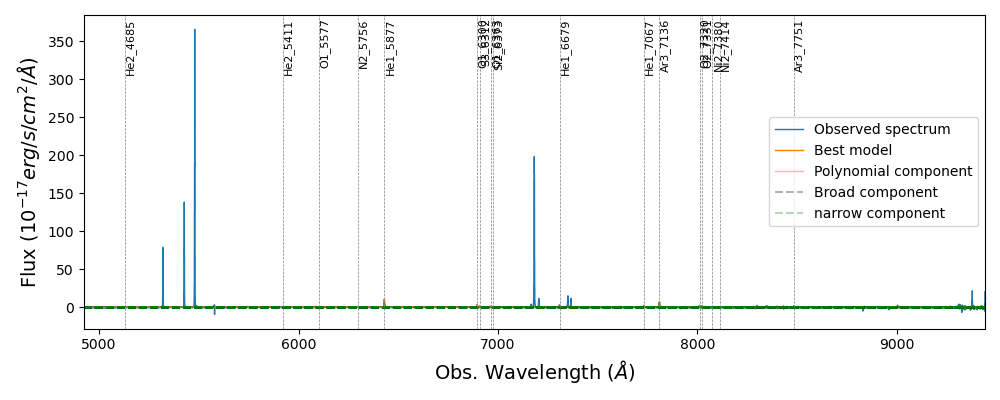

In [177]:
out_red = fitting_lines(wave2, flux2,
                    red_lines_f,
                    z_init=red.spectra.redshift,plot=True,
                    nfev=1000, fit=init, A_ratio=ratios)

In [14]:
main_DIR = "/Users/javieratoro/Desktop/thesis/"
proj_DIR = f"{main_DIR}proyecto 2024-2/"
code_DIR = f"{proj_DIR}codes"
os.chdir(code_DIR)

def MC_fluxes(class_, wave, flux):
    linelist = class_.spectra.linelist_dict
    bright_lines = ['H_14', 'H_13', 'O2_3725', 'O2_3727', 'H_alpha', 'H_beta',
                    'O3_5008', 'O3_4959', 'N2_6550', 'N2_6585',
                    'S2_6716','S2_6730']

    lines = class_.spectra.linelist_dict
    bright_dict = {k: v for k, v in linelist.items() if k in bright_lines}
    faint_dict  = {k: v for k, v in linelist.items() if k not in bright_lines}

    lines = [bright_dict, faint_dict]

    def fit(wave, flux, linelist):
        print('bright')
        bright = fitting_lines(wave, flux,
                    linelist[0],
                    z_init=class_.spectra.redshift,
                    nfev=1000, fit=None, A_ratio=None)
        print('bright done')
        ratios = a_ratio_dist(bright)
        print('faint')
        faint = fitting_lines(wave, flux,
                    linelist[1],
                    z_init=class_.spectra.redshift,
                    nfev=1000, fit=bright, A_ratio=ratios)
        print('faint done')
        return bright, faint

    bright, faint = fit(wave, flux, lines)

    fit_ = bright, faint
    return fit_, lines


def save_info(class_, num):
    columns = ['iter', 'n_eval_red', 'n_eval_blue' , 'success_red', 'success_blue',
               'message', 'ier', 'z',
               'sigma_v_narrow_red', 'sigma_v_broad_red', 'sigma_v_narrow_bright',
               'sigma_v_broad_bright']

    for label in class_.spectra.linelist_dict.keys():
        columns.append(str(label) + '_narrow')
        columns.append(str(label) + '_broad')

    df = pd.DataFrame(columns=columns)
    print('Starting MC iteration')
    i = 0
    n_success = 0

    while n_success < num:
        i += 1

        # ---- Safe noise generation
        noise = np.random.randn(len(class_.flux)) * class_.sigma
        flux_mc = class_.flux + noise

        result = MC_fluxes(class_, class_.wave, flux_mc)

        if result is None:
            print(f"Skipping MC iteration {i}")
            continue

        fits, labels = result
        bright, faint= fits

        row = {'iter': i + 1,
                'z': float(bright.params['z'].value),
                'sigma_v_narrow_bright': float(bright.params['sigma_v_narrow'].value),
                'sigma_v_broad_bright': float(bright.params['sigma_v_broad'].value),
                'sigma_v_narrow_faint': float(faint.params['sigma_v_narrow'].value),
                'sigma_v_broad_faint': float(faint.params['sigma_v_broad'].value),
                'n_eval_faint': faint.nfev,
                'n_eval_bright': bright.nfev,
                'success_faint': faint.success,
                'success_bright': bright.success,
                'message': f"Blue: {bright.lmdif_message} | Red: {faint.lmdif_message}",
                'ier': [bright.ier, faint.ier]}
        for label, fit in zip(labels, fits):
            for label in label.keys():
                row[f"{label}_narrow"] = fit.params[f'{label}_narrow_amplitude'].value
                row[f"{label}_broad"] = fit.params[f'{label}_broad_amplitude'].value
    
        df.loc[len(df)] = row
        n_success += 1

    save_dir = f'{proj_DIR}lines/{class_.spectra.gal_id}/'
    os.makedirs(save_dir, exist_ok=True)
    df.to_csv(f'{save_dir}{class_.spectra.gal_id}_iter_parts.csv', index = False)
    return df

def save_data(class_, num):
    info = save_info(class_, num)
    df = pd.DataFrame(columns=['ID', 'mass', 'z', 'name', 'flux',
                               'fluxerr',
                               'narrow_flux', 'narrow_fluxerr',
                               'broad_flux', 'broad_fluxerr'])

    for label in class_.spectra.linelist_dict.keys():
        narrow_ = np.asarray(info[label+"_narrow"])
        broad_ = np.asarray(info[label+"_broad"])
        flux = narrow_ + broad_

        row = {'ID': class_.spectra.names[0],
            'mass': class_.spectra.mass,
            'z': np.median(info['z']),
            'name': label,
            'flux': np.median(flux),
            'fluxerr': np.std(flux),
            'narrow_flux': np.median(narrow_),
            'narrow_fluxerr': np.std(narrow_),
            'broad_flux': np.median(broad_),
            'broad_fluxerr': np.std(broad_),
        }
        df.loc[len(df)] = row

    save_dir = f'{proj_DIR}lines/{class_.spectra.gal_id}/'
    os.makedirs(save_dir, exist_ok=True)
    df.to_csv(f'{save_dir}{class_.spectra.gal_id}_model_parts.csv',
                index=False)
    print(f'Saving in {save_dir}')
    return df


In [213]:
np.median(ratios)*208.18594185794566/40.49130282642052

np.float64(1.101333450276112)

In [15]:
save_data(red, 2)

Starting MC iteration
bright
bright done
faint
faint done
bright
bright done
faint
faint done
Saving in /Users/javieratoro/Desktop/thesis/proyecto 2024-2/lines/J0328/


,ID,mass,z,name,flux,fluxerr,narrow_flux,narrow_fluxerr,broad_flux,broad_fluxerr
0,J0328+0031,9.8,0.085839,H_14,12.401335,1.372210,6.347717,1.722862,6.053618,3.095072
1,J0328+0031,9.8,0.085839,O2_3725,512.074034,1.481339,332.690106,3.911028,179.383928,2.429689
2,J0328+0031,9.8,0.085839,O2_3727,700.260204,0.868487,317.161562,1.157848,383.098642,0.289361
3,J0328+0031,9.8,0.085839,H_13,4.075038,0.670933,4.074870,0.670833,0.000169,0.000099
4,J0328+0031,9.8,0.085839,H_12,0.000170,0.000045,0.000098,0.000026,0.000071,0.000019
5,J0328+0031,9.8,0.085839,H_11,21.794661,0.484841,12.631402,0.209497,9.163259,0.275345
6,J0328+0031,9.8,0.085839,H_10,19.428383,0.634312,11.263493,0.431439,8.164890,0.202873
7,J0328+0031,9.8,0.085839,H_9,30.351183,0.277924,17.593583,0.260715,12.757600,0.017209
8,J0328+0031,9.8,0.085839,Ne3_3868,107.433165,0.876945,62.269367,0.155689,45.163798,0.721257
9,J0328+0031,9.8,0.085839,He1_3898,64.714928,0.346130,37.512308,0.413039,27.202620,0.066910


NameError: name 'np' is not defined

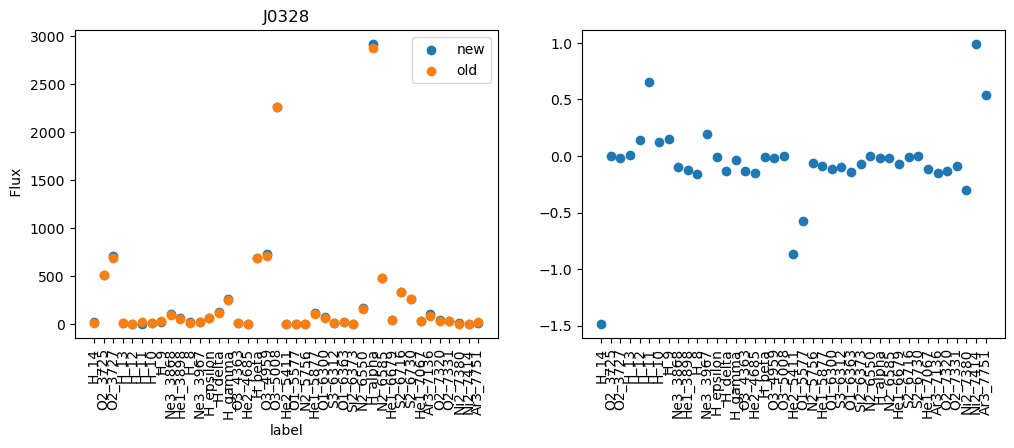

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
fig, axs =plt.subplots(1,2, figsize=(12, 4))
old = pd.read_csv('/Users/javieratoro/Desktop/thesis/proyecto 2024-2/lines/J0328/J0328_model.csv')
new = pd.read_csv('/Users/javieratoro/Desktop/thesis/proyecto 2024-2/lines/J0328/J0328_model_parts.csv')
new = new[(new['name'] != 'S2_4068') & (new['name'] != 'S2_4076')]

axs[0].scatter(old['name'], new['flux'], marker="o", label='new')
axs[0].scatter(old['name'], old['flux'], marker="o", label='old')
axs[0].tick_params(axis='x', rotation=90)
axs[0].set_xlabel('label')
axs[0].set_ylabel(' Flux')
axs[0].set_title('J0328')
axs[0].legend()

axs[1].scatter(old['name'], (old['flux'].values-new['flux'].values)/old['flux'].values, marker="o")
axs[1].tick_params(axis='x', rotation=90)
axs[1].plot(old['name'], np.zeros(len(old['flux'])), ls='dotted', color='grey')
axs[1].set_ylabel('Absolute difference')

plt.tight_layout()
plt.show()

In [18]:
def fit_auroral_new(class_, ratio, flux_, showplot=False):

    auroral_lines = ['S2_4068', 'O3_4363',
                     'N2_5756', 'O1_6300',
                     'O1_6363', 'S3_6312',
                     'O2_7320']

    # get info from lines
    stamps, sigmas, fits = [], [], []

    wave, flux = class_.wave.copy(), flux_.copy()

    params = pd.read_csv(f'{proj_DIR}lines/{class_.spectra.gal_id}/'
                         f'{class_.spectra.gal_id}_iter_parts.csv')

    cte = (1 + class_.spectra.redshift)

    # dataframe setup
    columns = ['sigma_v_narrow', 'sigma_v_broad']
    for label in auroral_lines:
        columns += [f'{label}_narrow_amplitude',
                    f'{label}_broad_amplitude']
    columns += ['O2_7331_narrow_amplitude', 'O2_7331_broad_amplitude',
                'S2_4076_narrow_amplitude', 'S2_4076_broad_amplitude']

    df = pd.DataFrame(columns=columns)

    row = {col: np.nan for col in df.columns}

    # get stamps
    for auroral in auroral_lines:
        if auroral == 'O2_7320':
            exclude_labels = ['O2_7320', 'O2_7331']
        elif auroral == 'S2_4068':
            exclude_labels = ['S2_4068', 'S2_4076']
        else:
            exclude_labels = [auroral]

        wave_copy, flux_copy = wave.copy(), flux.copy()

        lam = class_.spectra.linelist_dict[auroral]
        center = lam * cte
        # get sigma for each line according to the line wavelength
        if lam > 4500:
            sigma_v_broad = np.median(params['sigma_v_broad_red'])
            sigma_v_narrow = np.median(params['sigma_v_narrow_red'])
        else:
            sigma_v_broad = np.median(params['sigma_v_broad_bright'])
            sigma_v_narrow = np.median(params['sigma_v_narrow_bright'])
        sigmas.append([sigma_v_narrow, sigma_v_broad])
        print(sigma_v_narrow, sigma_v_broad)


        center = class_.spectra.linelist_dict[auroral] * (1+class_.spectra.redshift)
        sep = 35
        mask = (wave > center - sep) & (wave < center + sep)
        wave_line, flux_line = wave_copy[mask], flux_copy[mask]

        for l_ in class_.spectra.linelist_dict.keys():
            if exclude_labels and l_ in exclude_labels:
                continue
            c_ = class_.spectra.linelist_dict[l_] * (1+class_.spectra.redshift)
            if center - sep < c_ < center + sep:
                mask2 = (wave_line > c_ - 0.1*sigma_v_narrow) & (wave_line < c_ + 0.1*sigma_v_narrow)
                flux_line[mask2] = np.nan

        med = np.nanmedian(flux_line)
        flux_line[flux_line < -2] = np.nan

        stamps.append((wave_line, flux_line))

        # Create model for line
        na_gss = [GaussianModel(prefix=f"{lab}_narrow_") for lab in exclude_labels]
        br_gss = [GaussianModel(prefix=f"{lab}_broad_") for lab in exclude_labels]

        if len(exclude_labels) == 1:
            sum_of_gaussians = na_gss[0] + br_gss[0]
        else:
            sum_of_gaussians = br_gss[0] + na_gss[0]
            for narrow, broad_value in zip(na_gss[1:], br_gss[1:]):
                sum_of_gaussians += (broad_value + narrow)

        polynomial = PolynomialModel(degree=1)
        comp_mult = sum_of_gaussians + polynomial

        pars_mult = comp_mult.make_params()

        for i in range(2):
            pars_mult[f'c{i}'].set(value=0, vary=False)

        pars_mult.add(name='z', value=class_.spectra.redshift, vary=True)
        pars_mult.add(name='sigma_v_narrow', value=sigma_v_narrow, vary=False)
        pars_mult.add(name='sigma_v_broad', value=sigma_v_broad, vary=False, max=500)

        for lab in exclude_labels:
            lam = class_.spectra.linelist_dict[lab]
            # narrow
            pars_mult[f"{lab}_narrow_center"] = Parameter(
                name=f"{lab}_narrow_center",
                value=lam, vary=True,
                expr=f'{lam:6.2f}*(1+z)'
            )
            pars_mult[f"{lab}_narrow_amplitude"] = Parameter(
                name=f"{lab}_narrow_amplitude",
                value=1, vary=True, expr=None, min=0.0
            )
            pars_mult[f"{lab}_narrow_sigma"] = Parameter(
                name=f"{lab}_narrow_sigma",
                value=lam, vary=False,
                expr=f'(sigma_v_narrow/3e5)*{lab}_narrow_center'
            )
            # broad
            pars_mult[f"{lab}_broad_center"] = Parameter(
                name=f"{lab}_broad_center",
                value=lam, vary=True,
                expr=f'{lam:6.2f}*(1+z)'
            )


            pars_mult['A_ratio'] = Parameter(
                name='A_ratio',
                value=np.median(ratio),
                vary=False,
                expr= f'{np.median(ratio)}*(sigma_v_broad/sigma_v_narrow)'
            )

            pars_mult[f'{lab}_broad_amplitude'] = Parameter(
                name=f'{lab}_broad_amplitude', vary=False,
                expr=f'A_ratio*{lab}_narrow_amplitude'
            )

            pars_mult[f"{lab}_broad_sigma"] = Parameter(
                name=f"{lab}_broad_sigma",
                value=lam, vary=False,
                expr=f'(sigma_v_broad/3e5)*{lab}_broad_center'
            )

        # Fitting line
        fit = comp_mult.fit(flux_line, pars_mult, x=wave_line,
                            nan_policy='omit', max_nfev=1000)

        fits.append(fit)

        for label in exclude_labels:
            row['sigma_v_narrow']= sigma_v_narrow
            row['sigma_v_broad'] = sigma_v_broad
            name_narrow = f"{label}_narrow_amplitude"
            name_broad = f"{label}_broad_amplitude"
            row[name_narrow] = float(fit.params[name_narrow].value)
            row[name_broad] = float(fit.params[name_broad].value)

    df.loc[len(df)] = row

    if showplot:
        fig, axes = plt.subplots(3, 3, figsize=(13, 11))
        for stamp, fit, ax, label in zip(stamps, fits,
                                         axes.flatten(), auroral_lines):
            wave_line, flux_line = stamp
            comp = fit.eval_components(x=wave_line)
            best = fit.eval(x=wave_line)
            ax.plot(wave_line, flux_line, drawstyle='steps-mid', color='blue',
                    label='Observed data', alpha=0.5)

            ax.plot(wave_line, best, 'black', lw=1,
                        label='Fit spectra', drawstyle='steps-mid')
            ax.plot(wave_line,
                        comp[f'{label}_narrow_'] + comp['polynomial'],
                        'green', linestyle='--', lw=1, alpha=0.5,
                        drawstyle='steps-mid', label='Narrow component')
            ax.plot(wave_line,
                        comp[f'{label}_broad_'] + comp['polynomial'],
                        'red', linestyle='--', lw=1, alpha=0.5,
                        drawstyle='steps-mid', label='Broad component')
            # ax.set_ylim([-1, 20])
            # ax.set_xlim([np.min(best) - 5, np.max(best) + 5])
            ax.set_xlabel(r'Obs. Wavelength ($\AA$)', size=14)
            ax.set_ylabel(r'Flux ($10^{-17} erg/s/cm^{2}/\AA$)', size=14)
            ax.set_title(f'{label}')
            if label == 'O2_7320':
                ax.plot(wave_line,
                        comp['O2_7331_narrow_'] + comp['polynomial'],
                        'green', linestyle='--', lw=1, alpha=0.5,
                        drawstyle='steps-mid', label='Narrow component')
                ax.plot(wave_line,
                        comp['O2_7331_broad_'] + comp['polynomial'],
                        'red', linestyle='--', lw=1, alpha=0.5,
                        drawstyle='steps-mid', label='Broad component')
                ax.set_title(f'{label}, O2_7331')
            if label == 'S2_4068':
                ax.plot(wave_line,
                        comp['S2_4076_narrow_'] + comp['polynomial'],
                        'green', linestyle='--', lw=1, alpha=0.5,
                        drawstyle='steps-mid', label='Narrow component')
                ax.plot(wave_line,
                        comp['S2_4076_broad_'] + comp['polynomial'],
                        'red', linestyle='--', lw=1, alpha=0.5,
                        drawstyle='steps-mid', label='Broad component')
                ax.set_title(f'{label}, S2_4076')
        axes[0, 2].legend(bbox_to_anchor=(1, 1.6), loc='upper right')
        axes[2, 2].axis('off')
        axes[2, 1].axis('off')
        plt.tight_layout()
        plt.show()
    return fits, df

def save_data_auroral_MC(class_, ratio, num):
    auroral_lines = ['S2_4068', 'O3_4363',
                    'N2_5756', 'O1_6300',
                    'O1_6363', 'S3_6312',
                    'O2_7320']
    comps = []

    # dataframe setup
    columns = ['sigma_v_narrow', 'sigma_v_broad']
    for label in auroral_lines:
        columns += [f'{label}_narrow_amplitude',
                    f'{label}_broad_amplitude']
    columns += ['O2_7331_narrow_amplitude', 'O2_7331_broad_amplitude',
                'S2_4076_narrow_amplitude', 'S2_4076_broad_amplitude']

    info = pd.DataFrame(columns=columns)

    for i in range(num):
        yoff = np.random.randn(len(class_.flux)) * class_.sigma
        fit, df = fit_auroral_new(class_, ratio, flux_=class_.flux + yoff)
        info = pd.concat([info, df], ignore_index=True)
        comps.append(fit)

    res = pd.DataFrame(columns=['ID', 'mass', 'z', 'name', 'flux',
                            'fluxerr',
                            'narrow_flux', 'narrow_fluxerr',
                            'broad_flux', 'broad_fluxerr'])

    for label in info.columns[2:]:
        if 'broad' in label:
            continue
        else:
            label = label[:7]
            narrow_ = np.asarray(info[label+"_narrow_amplitude"])
            broad_ = np.asarray(info[label+"_broad_amplitude"])
            flux = narrow_ + broad_
            row = {'ID': class_.spectra.names[0],
                    'mass': class_.spectra.mass,
                    'z': class_.spectra.redshift,
                    'name': label,
                    'flux': np.median(flux),
                    'fluxerr': np.std(flux),
                    'narrow_flux': np.median(info[label+"_narrow_amplitude"]),
                    'narrow_fluxerr': np.std(info[label+"_narrow_amplitude"]),
                    'broad_flux': np.median(info[label+"_broad_amplitude"]),
                    'broad_fluxerr': np.std(info[label+"_broad_amplitude"])}
            res.loc[len(res)] = row

    res.to_csv(f'{proj_DIR}lines/{class_.spectra.gal_id}/'
                f'{class_.spectra.gal_id}_auroral_model_parts.csv',
                index=False)
    info.to_csv(f'{proj_DIR}lines/{class_.spectra.gal_id}/'
                f'{class_.spectra.gal_id}_auroral_iter_parts.csv',
                index=False)

    return info, res


40.854008550862865 319.31003889144813
40.854008550862865 319.31003889144813
38.09725184116603 70.0000148057639
38.09725184116603 70.0000148057639
38.09725184116603 70.0000148057639
38.09725184116603 70.0000148057639
38.09725184116603 70.0000148057639


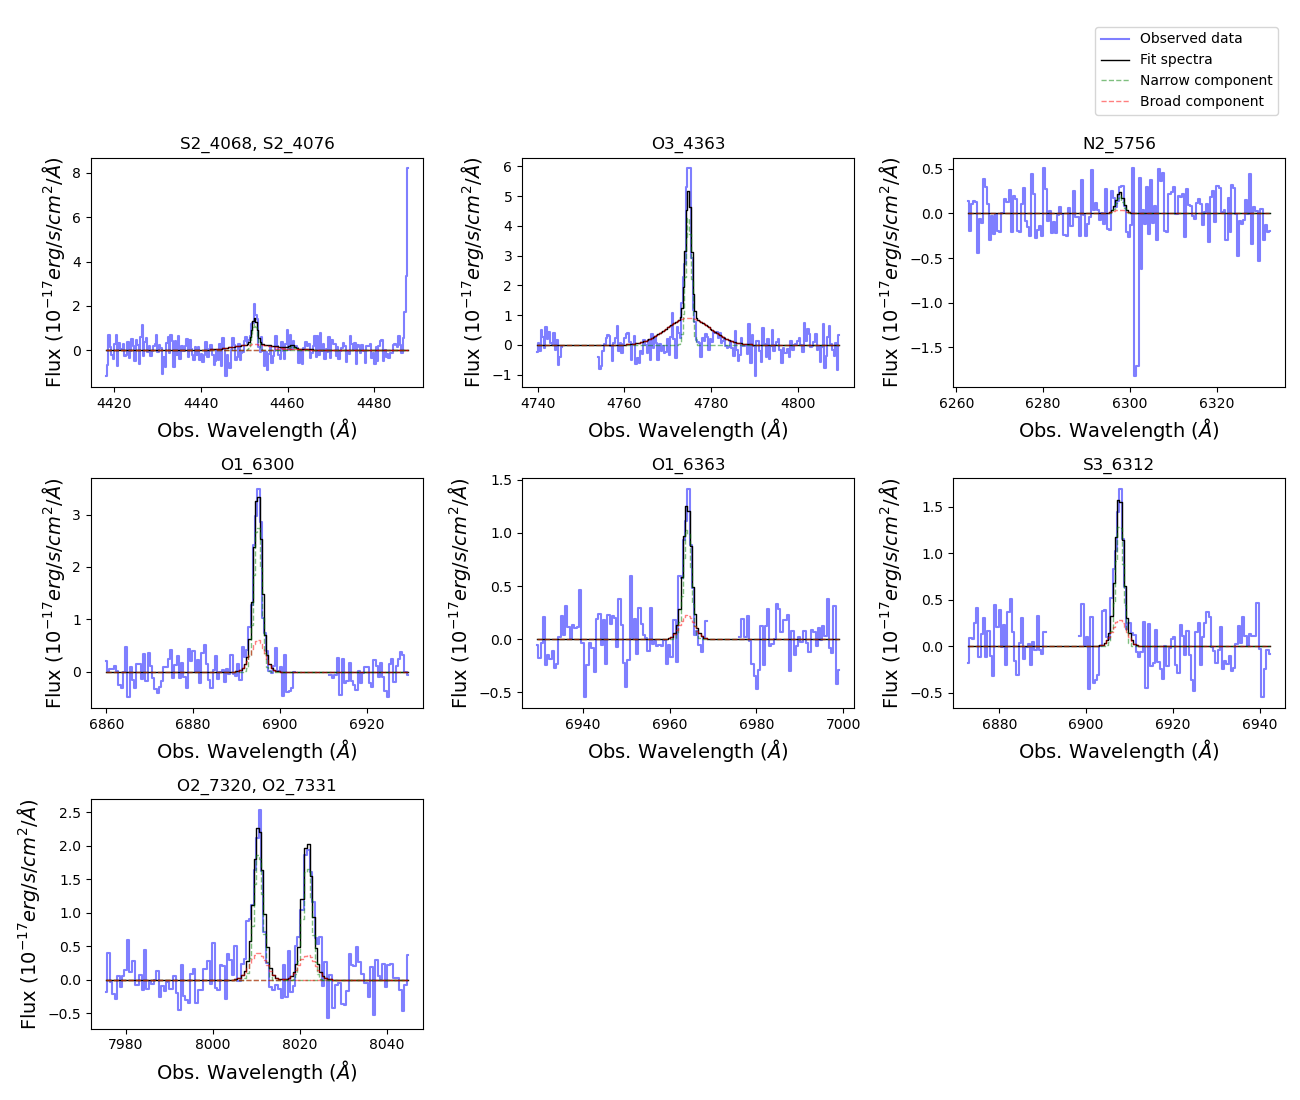

In [19]:
a, b = fit_auroral_new(red, ratio=ratios, flux_=red.flux, showplot=True)

In [343]:
info, res = save_data_auroral_MC(red, ratio=ratios, num=100)

/var/folders/b3/z1vmt1t542ncmpppx7tfrqd80000gn/T/ipykernel_5718/1683139633.py:200: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  info = pd.concat([info, df], ignore_index=True)


In [260]:
res

,ID,mass,z,name,flux,fluxerr,narrow_flux,narrow_fluxerr,broad_flux,broad_fluxerr
0,J0328+0031,9.8,0.085829,S2_4068,1.165987e+01,0.929713,6.991198e+00,0.557451,4.668669e+00,0.372262
1,J0328+0031,9.8,0.085829,O3_4363,1.342704e+01,0.651280,8.050788e+00,0.390504,5.376255e+00,0.260776
2,J0328+0031,9.8,0.085829,N2_5756,5.720705e+00,0.643576,3.210248e+00,0.361151,2.510457e+00,0.282425
3,J0328+0031,9.8,0.085829,O1_6300,7.638808e+01,0.670007,4.286616e+01,0.375983,3.352192e+01,0.294024
4,J0328+0031,9.8,0.085829,O1_6363,2.565936e+01,0.649397,1.439908e+01,0.364417,1.126028e+01,0.284979
5,J0328+0031,9.8,0.085829,S3_6312,1.178474e+01,0.587980,6.613161e+00,0.329953,5.171582e+00,0.258027
6,J0328+0031,9.8,0.085829,O2_7320,4.239144e+01,1.016248,2.378851e+01,0.570281,1.860294e+01,0.445967
7,J0328+0031,9.8,0.085829,O2_7331,3.699624e+01,0.900720,2.076092e+01,0.505450,1.623532e+01,0.395269
8,J0328+0031,9.8,0.085829,S2_4076,1.861177e-08,0.080533,1.115952e-08,0.048287,7.452244e-09,0.032246


NameError: name 'np' is not defined

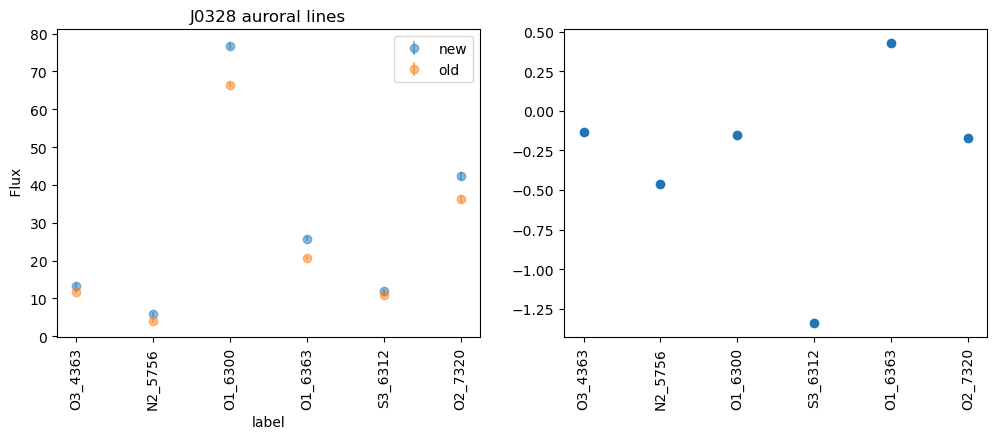

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
fig, axs =plt.subplots(1,2, figsize=(12, 4))
old = pd.read_csv('/Users/javieratoro/Desktop/thesis/proyecto 2024-2/lines/J0328/J0328_model.csv')
new = pd.read_csv('/Users/javieratoro/Desktop/thesis/proyecto 2024-2/lines/J0328/J0328_auroral_model_parts.csv')
auroral_lines = ['N2_5756', 'O1_6300',
                    'O1_6363', 'O3_4363',
                    'S3_6312', 'O2_7320']

old_filtered = old[old['name'].isin(auroral_lines)]
new_filtered = new[new['name'].isin(auroral_lines)]

# axs[0].scatter(old_filtered['name'], new_filtered['flux'], marker="o", label='new')
# axs[0].scatter(old_filtered['name'], old_filtered['flux'], marker="o", label='old')
axs[0].errorbar(new_filtered['name'], new_filtered['flux'],
                yerr=new_filtered['fluxerr'], fmt='o', label='new', alpha=0.5)
axs[0].errorbar(old_filtered['name'], old_filtered['flux'],
                yerr=old_filtered['fluxerr'], fmt='o', label='old', alpha=0.5)
axs[0].tick_params(axis='x', rotation=90)
axs[0].set_xlabel('label')
axs[0].set_ylabel(' Flux')
axs[0].set_title('J0328 auroral lines')
axs[0].legend()

axs[1].scatter(old_filtered['name'], (old_filtered['flux'].values-new_filtered['flux'].values)/old_filtered['flux'].values, marker="o")
axs[1].tick_params(axis='x', rotation=90)
axs[1].plot(old_filtered['name'], np.zeros(len(old_filtered['flux'])), ls='dotted', color='grey')
axs[1].set_ylabel('Absolute difference')

plt.tight_layout()
plt.show()

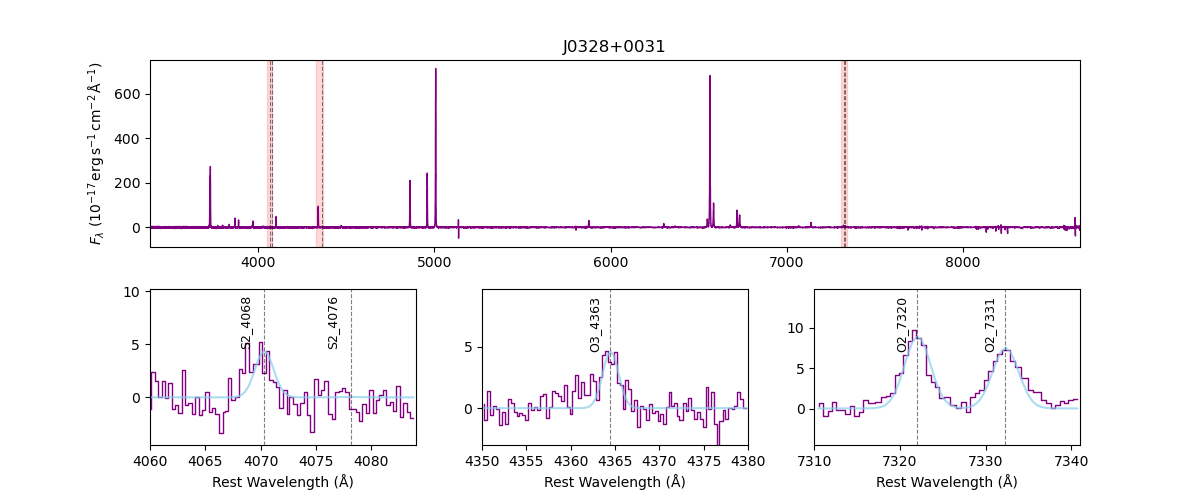

In [268]:
wave, flux = red.wave, red.flux
lines = red.spectra.linelist_dict
cte = (1 +red.spectra.redshift)
wave = wave / cte
fit = fit_all

fig = plt.figure(figsize=(12, 5))
grid = fig.add_gridspec(2, 1, height_ratios=[1.2, 1.0], hspace=0.25)

# -------- Top panel (full spectrum) --------
ax0 = fig.add_subplot(grid[0, 0])
ax0.step(wave, flux, color="purple", lw=1)

masked_regions = [(4050, 4080), (4330, 4370), (7310, 7340)]

# Shaded mask regions
for m0, m1 in masked_regions:
    ax0.axvspan(m0, m1, color='red', alpha=0.15)

ax0.set_ylabel(r"$F_\lambda$ $(10^{-17}\, \mathrm{erg\,s^{-1}\,cm^{-2}\,Å^{-1}})$")
ax0.set_xlim(wave.min(), wave.max())
ax0.set_title(red.spectra.names[0])

gs_zoom = grid[1].subgridspec(1, len(masked_regions), wspace=0.25)

emission_lines = [(4060, 4084), (4350, 4380), (7310, 7341)]
for i, (xmin, xmax) in enumerate(emission_lines):
    ax = fig.add_subplot(gs_zoom[i])
    m = (wave >= xmin) & (wave <= xmax)

    ax.step(wave[m], flux[m], color="purple", lw=1)
    ax.plot(wave[m], fit.best_fit[m], color='skyblue', alpha =0.7)
    ax.set_ylim(-2, np.max(flux[m])+5)


    # emission lines in this window
    for label, lam in lines.items():
        if xmin < lam < xmax:
            ax.axvline(lam, color="black", ls="--", lw=0.8, alpha=0.5)
            ax0.axvline(lam, color="black", ls="--", lw=0.8, alpha=0.5)
            ax.text(lam-1, ax.get_ylim()[1]*0.95, label,
                    rotation=90, va="top", ha="right", fontsize=9)
            ax.set_ylim(ax.get_ylim()[0]*1.5, ax.get_ylim()[1])

    ax.set_xlim(xmin, xmax)
    ax.set_xlabel("Rest Wavelength (Å)")

plt.show()

In [3]:
wave_all, flux = red.wave, red.flux
lines = red.spectra.linelist_dict
cte = (1 +red.spectra.redshift)

wave_obs   = wave_all
wave_rest  = wave_all / cte
wave_rest1 = wave1 / cte
wave_rest2 = wave2 / cte

fig = plt.figure(figsize=(12, 5))
grid = fig.add_gridspec(2, 1, height_ratios=[1.2, 1.0], hspace=0.25)

# -------- Top panel (full spectrum) --------
ax0 = fig.add_subplot(grid[0, 0])
ax0.step(wave_rest, flux, color="purple", lw=1)

masked_regions = [ (4348, 4380), (7310, 7340), (4800, 5050), (6510, 6630)]

# Shaded mask regions
for m0, m1 in masked_regions:
    ax0.axvspan(m0, m1, color='red', alpha=0.15)

ax0.set_ylabel(r"$F_\lambda$ $(10^{-17}\, \mathrm{erg\,s^{-1}\,cm^{-2}\,Å^{-1}})$")
ax0.set_xlim(wave_rest.min(), wave_rest.max())
ax0.set_title(red.spectra.names[0])

gs_zoom = grid[1].subgridspec(1, len(masked_regions), wspace=0.25)


emission_lines = [ (4348, 4380), (7310, 7340), (4830, 5030), (6532, 6600)]
for i, (xmin, xmax) in enumerate(emission_lines):
    ax = fig.add_subplot(gs_zoom[i])
    m = (wave_rest >= xmin) & (wave_rest <= xmax)
    m1 = (wave_rest1 >= xmin) & (wave_rest1 <= xmax)
    m2 = (wave_rest2 >= xmin) & (wave_rest2 <= xmax)

    ax.step(wave_rest[m], flux[m], color="purple", lw=1)

    # emission lines in this window
    for label, lam in lines.items():
        if xmin < lam < xmax:
            if label == 'O3_4363':
                ax.step(
                    wave_rest1[m1],
                    out_red.best_fit[m1], lw=1,
                    color='skyblue', alpha=0.7
                )
                ax.set_ylim(-2, np.max(out_red.best_fit[m1])*1.5)
            if label == 'O2_7320':
                ax.step(
                    wave_rest2[m2],
                    out_blue.best_fit[m2], lw=1,
                    color='skyblue', alpha=0.7
                )
                ax.set_ylim(-0.8, np.max(out_blue.best_fit[m2])*1.5)
            else:
                ax.plot(
                    wave_rest[m],
                    init.best_fit[m], lw=1,
                    color='skyblue', alpha=0.7
                )

            ax.axvline(lam, color="black", ls="--", lw=0.8, alpha=0.5)
            ax0.axvline(lam, color="black", ls="--", lw=0.8, alpha=0.5)

            if label == 'O2_3727':
                ax.text(lam+2.2, ax.get_ylim()[1]*0.9, label,
                        rotation=90, va="top", ha="right", fontsize=9)
            else:
                ax.text(lam-1.5, ax.get_ylim()[1]*0.9, label,
                        rotation=90, va="top", ha="right", fontsize=9)

    ax.set_xlim(xmin, xmax)
    ax.set_xlabel("Rest Wavelength (Å)")
plt.show()

NameError: name 'red' is not defined

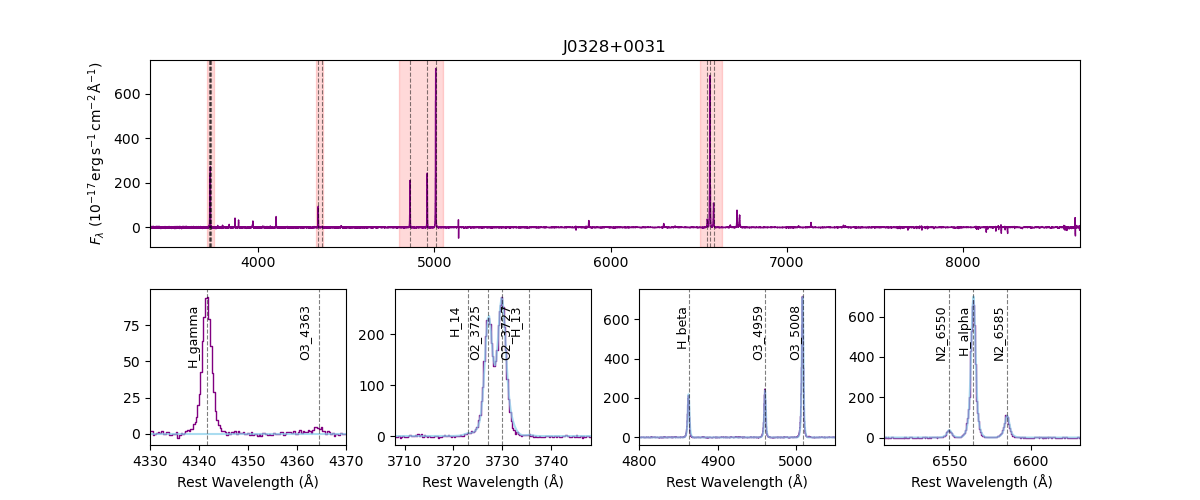

In [269]:
wave, flux = red.wave, red.flux
lines = red.spectra.linelist_dict
cte = (1 +red.spectra.redshift)
wave = wave / cte

fig = plt.figure(figsize=(12, 5))
grid = fig.add_gridspec(2, 1, height_ratios=[1.2, 1.0], hspace=0.25)

# -------- Top panel (full spectrum) --------
ax0 = fig.add_subplot(grid[0, 0])
ax0.step(wave, flux, color="purple", lw=1)

masked_regions = [ (4330, 4370), (3708, 3748), (4800, 5050), (6510, 6630)]

# Shaded mask regions
for m0, m1 in masked_regions:
    ax0.axvspan(m0, m1, color='red', alpha=0.15)

ax0.set_ylabel(r"$F_\lambda$ $(10^{-17}\, \mathrm{erg\,s^{-1}\,cm^{-2}\,Å^{-1}})$")
ax0.set_xlim(wave.min(), wave.max())
ax0.set_title(red.spectra.names[0])

gs_zoom = grid[1].subgridspec(1, len(masked_regions), wspace=0.25)

for label, lam in lines.items():
    if label == 'O3_4363':
        fit = out_
    else:
        fit = init

for i, (xmin, xmax) in enumerate(masked_regions):
    ax = fig.add_subplot(gs_zoom[i])
    m = (wave >= xmin) & (wave <= xmax)

    ax.step(wave[m], flux[m], color="purple", lw=1)
    ax.plot(wave[m], fit.best_fit[m], color='skyblue', alpha =0.7)


    # emission lines in this window
    for label, lam in lines.items():
        if xmin < lam < xmax:
            ax.axvline(lam, color="black", ls="--", lw=0.8, alpha=0.5)
            ax0.axvline(lam, color="black", ls="--", lw=0.8, alpha=0.5)
            if label == 'O2_3727':
                ax.text(lam+2.2, ax.get_ylim()[1]*0.9, label,
                        rotation=90, va="top", ha="right", fontsize=9)
            else:
                ax.text(lam-1.5, ax.get_ylim()[1]*0.9, label,
                        rotation=90, va="top", ha="right", fontsize=9)

    ax.set_xlim(xmin, xmax)
    ax.set_xlabel("Rest Wavelength (Å)")
    # ax.set_ylim(-10, 100)
plt.show()

## EW


In [ ]:
main_DIR = "/Users/javieratoro/Desktop/thesis/"
proj_DIR = f"{main_DIR}proyecto 2024-2/"
code_DIR = f"{proj_DIR}codes"

class BALMER_ABS:
    """
    Class to estimate and correct the Balmer absoprtion on a galaxy spectra.


    Receives the SPECTRALDATA class and a boolean for plotting the correction;
    and save the balmer-corrected spectra using a build-in model.

    """

    def __init__(self, spectra, showplot=False, verbose=False):
        self.spectra = spectra
        self.gal_id = self.spectra.names[0][:5]
        # Set Balmer lines names
        self.balmer_lines = ['H_gamma', 'H_delta',
                             'H_epsilon', 'H_8', 'H_9', 'H_10', 'H_11']

        # Read MW dust corrected data if it exist
        self.read_data()
        self.bal_abs_corr(plot=showplot)

    # @log_method_call
    def bal_abs_corr(self, plot=False):
        print(f'Performing Balmer absorption correction for {self.gal_id}')

        # Get sigma from first model
        sigmas = self.first_sigma_est()

        # Get stamps masked and unmasked
        self.get_stamp(sigmas)

        # Get model for each emission line
        self.model_absorption(self.stamps)

        # Apply balmer absorption correction
        new_flux = self.correct_data(self.stamps, self.comps, plot=plot)

        # Save data
        self.save_corrected_data(new_flux)

        print("Balmer absorption correction done!")

    def read_data(self):
        """
        Reads MW duct corrected data if it exist, otherwise reads the
        uncorrected data.
        """
        print(f'Reading data for {self.gal_id}')
        file_path = f'{proj_DIR}dust/{self.gal_id}/dcorr_{self.gal_id}.csv'
        if os.path.exists(file_path):
            print("Using MW dust corrected data")
            dcorr = pd.read_csv(file_path)
            arrays = dcorr.to_numpy().T  # Transpose to get column-wise array
            self.wave, self.flux, self.sigma = arrays

        else:
            print("Using uncorrected data")
            self.wave, self.flux, self.sigma, _ = self.spectra.datas[0]

    def first_sigma_est(self, plot=False):
        """
        Get the velocity dispersion (sigma) of the narrow and/or broad
        Gaussian components from the spectral fitting.

        Add plot=True to visualize the spectral fitting model
        """
        if self.spectra.model1IT is None:
            fit = fitSpectrum(self.wave, self.flux, self.sigma,
                              linelist=self.spectra.linelist_dict,
                              z_init=self.spectra.redshift,
                              showPlot=plot,
                              broad=True, nfev=1000)
            self.spectra.model1IT = fit
        else:
            fit = self.spectra.model1IT

        sigma_narrow = fit.params['sigma_v_narrow']
        sigma_broad = fit.params['sigma_v_broad']

        return [sigma_narrow, sigma_broad]

    def get_stamp(self, sigmas):
        """
        Create stamps for every emission line 25*sigma from center,
        masking the emission lines for future modelling.
        """
        self.masked_flux = self.flux.copy()
        self.stamps = []

        [sigma_narr, sigma_broad] = sigmas

        def get_sigma(label):
            if label == 'H_gamma':
                sigma = (center / const.c.to('km/s').value) * sigma_broad.value
            else:
                sigma = (center / const.c.to('km/s').value) * sigma_narr.value
            return sigma

        # Mask every emission line 3 sigma from center
        cte = (1 + self.spectra.redshift)
        for label in self.spectra.linelist_dict:
            center = self.spectra.linelist_dict[label] * cte
            sigma = get_sigma(label)

            size = 4.0
            mask_below = (self.wave > center - size*sigma)
            mask_up = (self.wave < center + size*sigma)
            mask_line = mask_below & mask_up

            # Every line to nan
            self.masked_flux[mask_line] = np.nan

        # Create the stamp 25 sigma from center
        for label in self.balmer_lines:
            center = self.spectra.linelist_dict[label] * cte
            sigma = get_sigma(label)
            sep = 50

            mask_below = (self.wave > center - sep*sigma)
            mask_up = (self.wave < center + sep*sigma)
            mask_stamp = mask_below & mask_up

            masked_stamp = self.masked_flux[mask_stamp]
            stamp = self.flux[mask_stamp]
            masked_wave = self.wave[mask_stamp]

            self.stamps.append([masked_wave, stamp, masked_stamp])
        return self.stamps

    def model_absorption(self, stamps):
        """
        Create the model for the absoption with a negative gaussian
        and a 1-degree polynomial
        """
        self.comps = []
        for label, stamp_ in zip(self.balmer_lines, stamps):
            masked_wave, _, masked_stamp = stamp_

            # Gaussian model for balmer abs
            gaussian = GaussianModel(prefix=label+'_')

            # Create a polynomial model for the continuum
            polydeg = 1
            polynomial = PolynomialModel(degree=polydeg)

            comp_mult = gaussian + polynomial
            pars_mult = comp_mult.make_params()

            pars_mult.add(name='z', value=self.spectra.redshift,
                          vary=False)

            # Loop through emission lines to define parameters
            # for narrow and broad

            lam = self.spectra.linelist_dict[label]
            center = lam * (1 + self.spectra.redshift)

            for param in ['center', 'amplitude', 'sigma']:
                narrow_key = f'{label}_{param}'
                if param == 'center':
                    value = lam
                    vary_ = False
                    min_ = None
                    max_ = None
                    expr = f'{lam:6.2f}*(1+z)'
                elif param == 'amplitude':
                    value = -30
                    vary_ = True
                    min_ = -100
                    max_ = 0
                    expr = None
                elif param == 'sigma':
                    value = (600 * center / const.c.to('km/s')).value
                    vary_ = False
                    min_ = (550 * center / const.c.to('km/s')).value
                    max_ = (700 * center / const.c.to('km/s')).value
                pars_mult[narrow_key] = Parameter(name=narrow_key,
                                                  value=value,
                                                  vary=vary_, expr=expr,
                                                  min=min_, max=max_)
            for i in range(polydeg+1):
                pars_mult[f'c{i:1.0f}'].set(value=0)

            out_comp_mult = comp_mult.fit(masked_stamp, pars_mult,
                                          x=masked_wave,
                                          nan_policy='omit',
                                          max_nfev=1000)

            self.comps.append(out_comp_mult)
        return self.comps

    def correct_data(self, stamps, comps, plot=False):
        """
        Compute the balmer correction and plot the correction if indicated
        """
        new_flux = self.flux.copy()
        wave = self.wave.copy()
        for stamp_, comp, label in zip(stamps, comps, self.balmer_lines):
            mask_wave, stamp, masked_stamp = stamp_
            mask = (wave >= np.min(mask_wave)) & (wave <= np.max(mask_wave))
            model_flux = comp.eval_components(x=mask_wave)
            balmer_abs = model_flux[f'{label}_']
            new_flux[mask] -= balmer_abs

            if plot:
                _, axs = plt.subplots(1, 3, figsize=(12, 4))
                axs[0].plot(mask_wave, stamp, lw=1, drawstyle='steps-mid',
                            alpha=0.5)
                axs[0].plot(mask_wave,
                            model_flux[f'{label}_'] + model_flux['polynomial'],
                            lw=1, drawstyle='steps-mid',
                            label='Balmer abs model')
                axs[0].set_title(f'{label} balmer absorption')
                axs[0].set_xlabel(r'Wavelength $\AA$')
                axs[0].set_ylabel(r'Flux (erg / s / cm$^{2}$)')
                axs[0].set_ylim(np.mean(model_flux['polynomial'])-10,
                                np.mean(model_flux['polynomial'])+10)
                axs[0].legend()
                axs[1].plot(mask_wave, stamp, lw=1, drawstyle='steps-mid',
                            alpha=0.5)
                axs[1].plot(mask_wave, masked_stamp,
                            lw=1, drawstyle='steps-mid',
                            label='Masked spectra')
                axs[1].set_xlabel(r'Wavelength $\AA$')
                axs[1].set_ylabel(r'Flux (erg / s / cm$^{2}$)')
                axs[1].set_ylim(np.mean(model_flux['polynomial'])-10,
                                np.mean(model_flux['polynomial'])+10)
                axs[1].legend()
                axs[2].plot(wave[mask], stamp, alpha=0.5,
                            lw=1, drawstyle='steps-mid',
                            label='Uncorrected flux')
                axs[2].plot(wave[mask], new_flux[mask], alpha=0.5,
                            lw=1, drawstyle='steps-mid',
                            label='Corrected flux')
                axs[2].plot(wave[mask], model_flux['polynomial'],
                            alpha=0.3, label='Continuum')
                axs[2].set_xlabel(r'Wavelength $\AA$')
                axs[2].set_ylabel(r'Flux (erg / s / cm$^{2}$)')
                axs[2].set_ylim(np.mean(model_flux['polynomial'])-10,
                                np.mean(model_flux['polynomial'])+10)
                axs[2].legend()
                save_dir = f'{proj_DIR}bal_abs/{self.gal_id}'
                os.makedirs(save_dir, exist_ok=True)
                path = f'{save_dir}/{label}_balabs.pdf'
                plt.savefig(path,
                            format='pdf')
                plt.show()
        return new_flux

    def EW(self):
        res = pd.DataFrame(columns=['ID', 'z', 'name', 'sigma', 'EW'])
        for comp, label, stamp_ in zip(self.comps, self.balmer_lines,
                                       self.stamps):
            mask_wave, _, _ = stamp_
            A = comp.params[f'{label}_amplitude']
            cont = np.mean(comp.eval_components(x=mask_wave)['polynomial'])
            EW = A/cont
            center = comp.params[f'{label}_center']
            sigma = comp.params[f'{label}_sigma']*const.c.to('km/s')/center

            row = {'ID': self.spectra.names[0],
                   'z': self.spectra.redshift,
                   'name': label,
                   'sigma': sigma.value,
                   'EW': EW
                   }
            res.loc[len(res)] = row

        fig, axs = plt.subplots(1, 2, figsize=(12, 4))
        axs[0].scatter(res['EW'].index + 4, -res['EW'])
        axs[0].set_xlabel('Balmer order')
        axs[0].set_ylabel('EW')
        axs[1].set_ylabel('sigma [km/s]')
        axs[1].set_xlabel('Balmer order')
        axs[1].scatter(res['sigma'].index + 4, res['sigma'])
        plt.show()

        save_dir = f'{proj_DIR}bal_abs'
        save_path = f'{save_dir}/{self.gal_id}_EW.csv'
        os.makedirs(save_dir, exist_ok=True)
        res.to_csv(save_path, index=False)
        return res

    def save_corrected_data(self, new_flux):
        """
        Saves the corrected data to a CSV file,
        creating the directory if needed.
        """
        # Define the directory and file path
        save_dir = f'{proj_DIR}bal_abs'
        save_path = f'{save_dir}/bcorr_{self.gal_id}.csv'

        # Create the directory if it doesn't exist
        os.makedirs(save_dir, exist_ok=True)

        # Create and save DataFrame
        df = pd.DataFrame({'wave': self.wave, 'flux': new_flux,
                           'sigma': self.sigma})
        df.to_csv(save_path, index=False)

        # IMAGES(self.spectra, [(self.wave, new_flux)], ['Balmer corrected'],
        #        f'{proj_DIR}bal_abs', f'bcorr_{self.gal_id}')

        print(f'Saved Balmer Absorption corrected data to: {save_path}')

Reading data for J0328
Using MW dust corrected data
Performing Balmer absorption correction for J0328


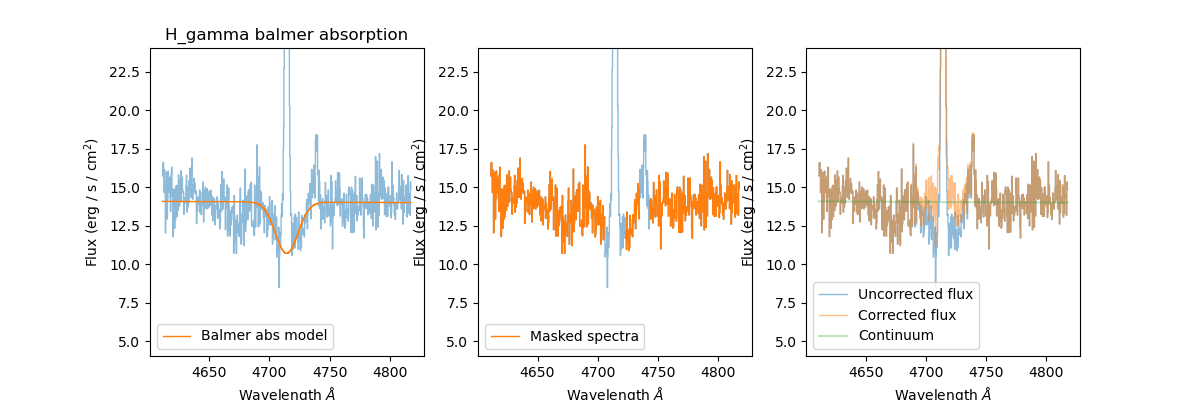

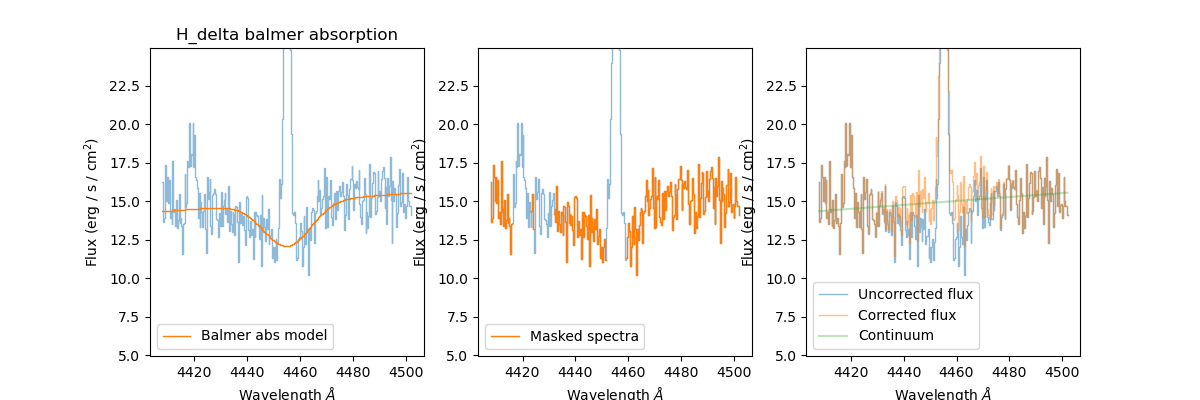

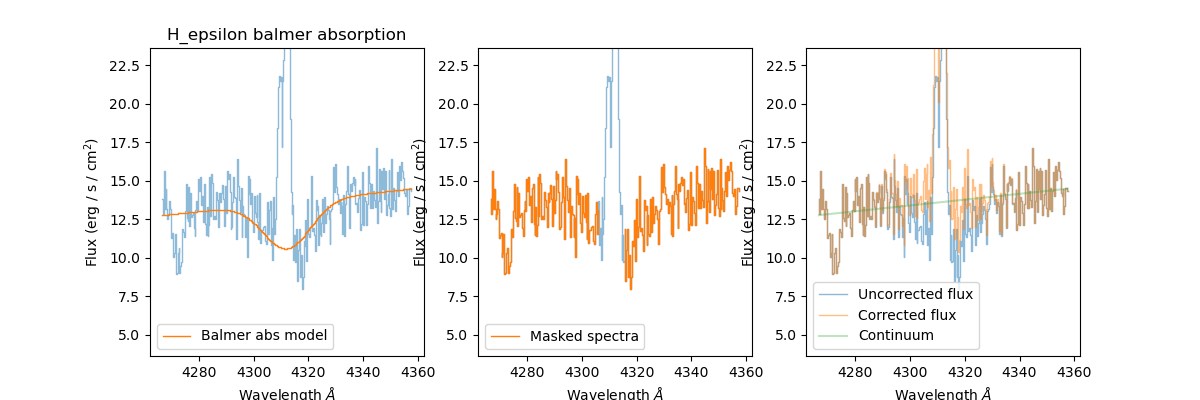

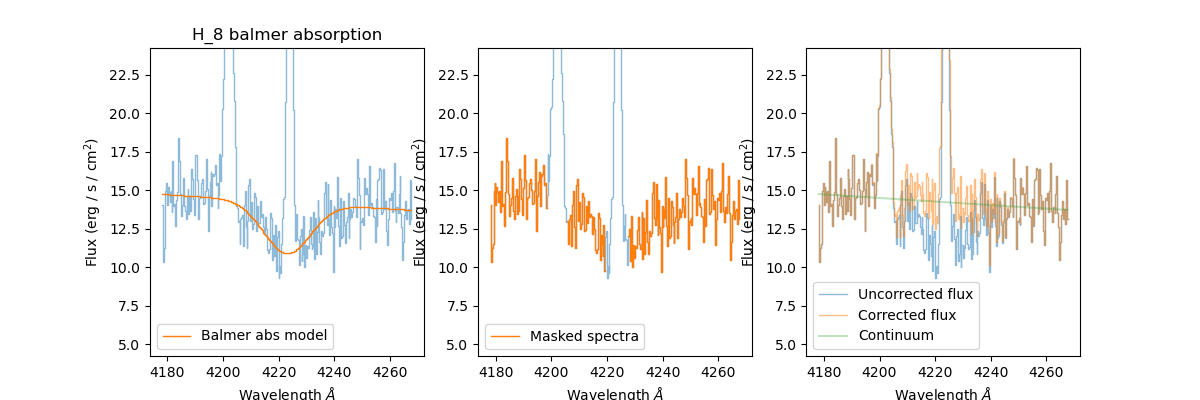

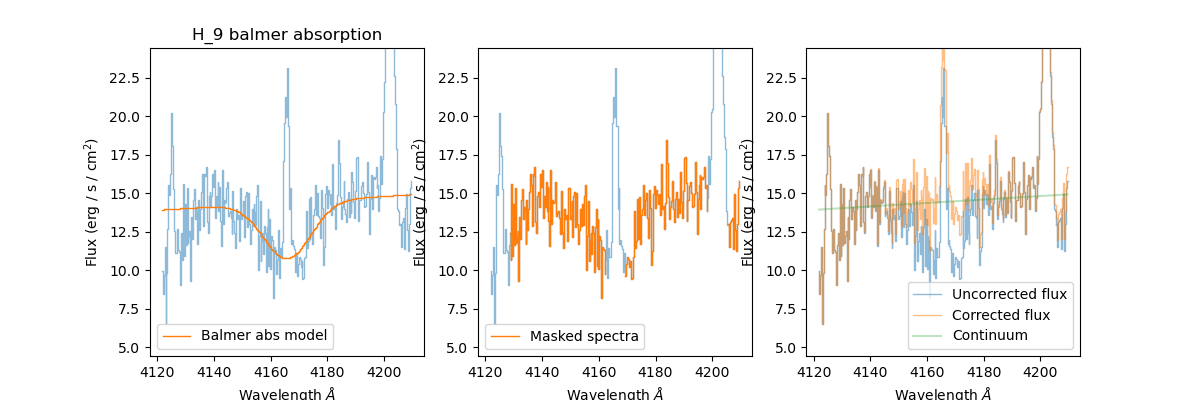

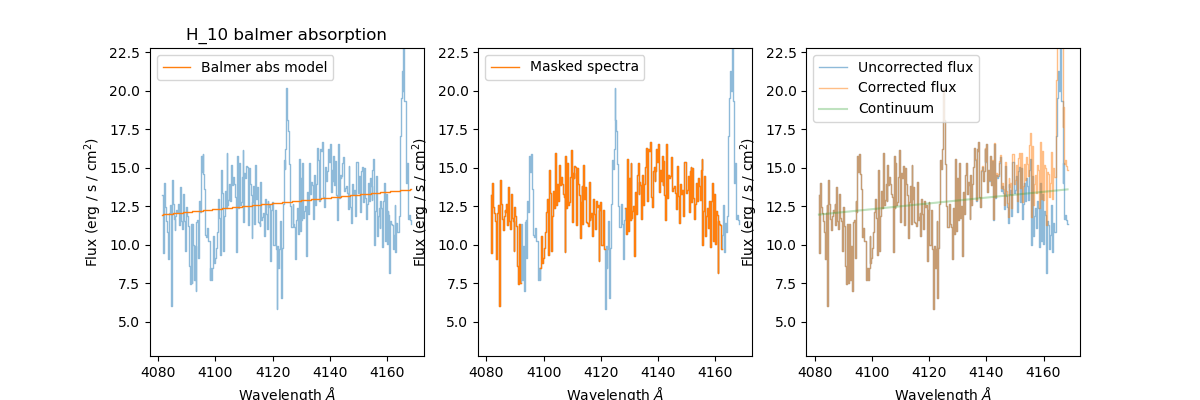

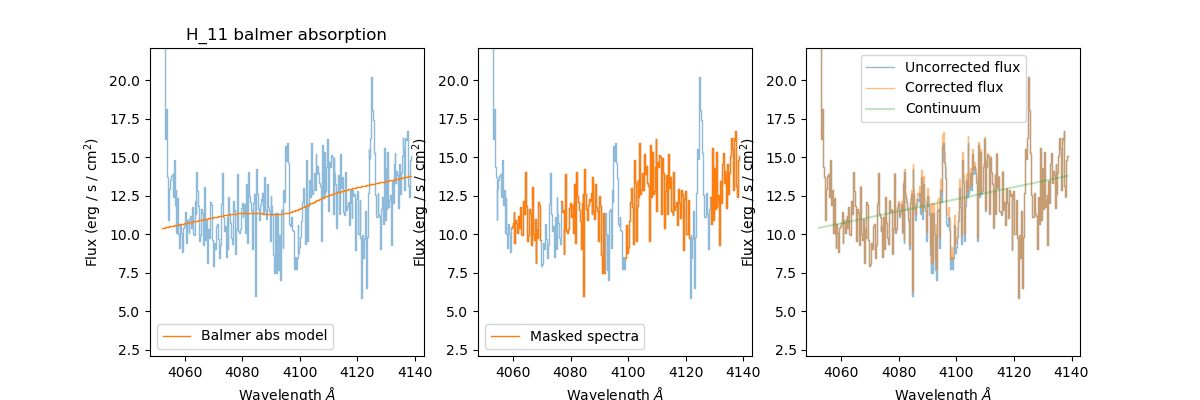

Saved Balmer Absorption corrected data to: /Users/javieratoro/Desktop/thesis/proyecto 2024-2/bal_abs/bcorr_J0328.csv
Balmer absorption correction done!


In [35]:
b = BALMER_ABS(J0328, showplot=True)

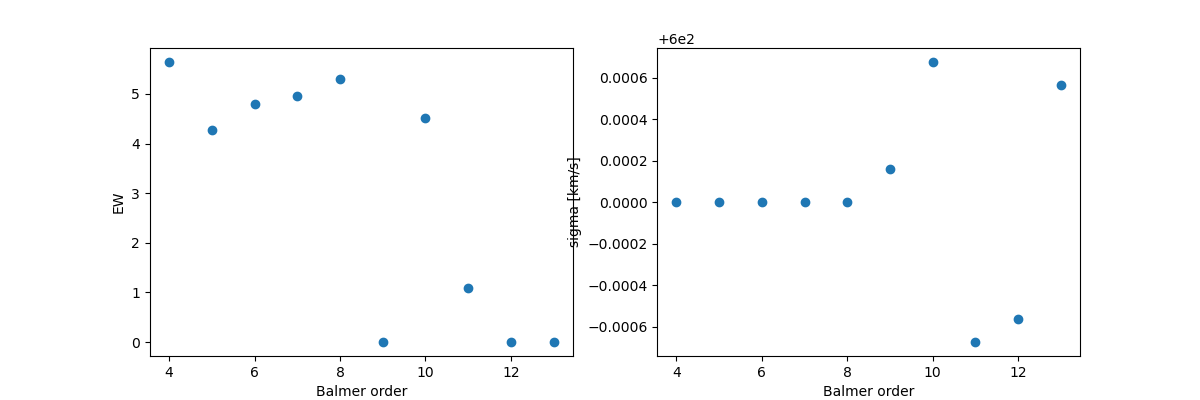

,ID,z,name,sigma,EW
0,J0328+0031,0.085829,H_gamma,600.000000,-5.643812
1,J0328+0031,0.085829,H_delta,600.000000,-4.277196
2,J0328+0031,0.085829,H_epsilon,600.000000,-4.802183
3,J0328+0031,0.085829,H_8,600.000000,-4.951438
4,J0328+0031,0.085829,H_9,600.000000,-5.300596
5,J0328+0031,0.085829,H_10,600.000158,-0.000189
6,J0328+0031,0.085829,H_11,600.000675,-4.522586
7,J0328+0031,0.085829,H_12,599.999327,-1.095613
8,J0328+0031,0.085829,H_13,599.999438,-0.000008
9,J0328+0031,0.085829,H_14,600.000564,-0.000002


In [225]:
b.EW()

In [181]:
def read_data(class_):
    """
    Reads MW duct corrected data if it exist, otherwise reads the
    uncorrected data.
    """
    print(f'Reading data for {class_.gal_id}')
    file_path = f'{proj_DIR}dust/{class_.gal_id}/dcorr_{class_.gal_id}.csv'
    if os.path.exists(file_path):
        print("Using MW dust corrected data")
        dcorr = pd.read_csv(file_path)
        arrays = dcorr.to_numpy().T  # Transpose to get column-wise array
        wave, flux, sigma = arrays

    else:
        print("Using uncorrected data")
        wave, flux, sigma, _ = class_.spectra.datas[0]
    return wave, flux, sigma

def first_sigma_est(wave, flux, sigma, list, z, plot=False):
    """
    Get the velocity dispersion (sigma) of the narrow and/or broad
    Gaussian components from the spectral fitting.

    Add plot=True to visualize the spectral fitting model
    """

    fit = fitSpectrum(wave, flux, sigma,
                        linelist=list,
                        z_init=z,
                        weights=1/sigma**2,
                        showPlot=plot,
                        broad=True, nfev=1000)

    sigma_narrow = fit.params['sigma_v_narrow']
    sigma_broad = fit.params['sigma_v_broad']

    return [sigma_narrow, sigma_broad]

    def get_stamp(class_, sigmas):
        """
        Create stamps for every emission line 25*sigma from center,
        masking the emission lines for future modelling.
        """
        class_.masked_flux = class_.flux.copy()
        class_.stamps = []

        [sigma_narr, sigma_broad] = sigmas

        def get_sigma(label):
            if label =='H_gamma':
                sigma = (center / const.c.to('km/s').value) * sigma_broad.value
            else:
                sigma = (center / const.c.to('km/s').value) * sigma_narr.value
            return sigma

        # Mask every emission line 3 sigma from center
        cte = (1 + class_.spectra.redshift)
        for label in class_.spectra.linelist_dict:
            center = class_.spectra.linelist_dict[label] * cte
            sigma = get_sigma(label)

            size = 4.0
            mask_below = (class_.wave > center - size*sigma)
            mask_up = (class_.wave < center + size*sigma)
            mask_line = mask_below & mask_up

            # Every line to nan
            class_.masked_flux[mask_line] = np.nan

        # Create the stamp 25 sigma from center
        for label in class_.balmer_lines:
            center = class_.spectra.linelist_dict[label] * cte
            sigma = get_sigma(label)
            sep = 20 if label in class_.balmer_lines[6:] else 50

            mask_below = (class_.wave > center - sep*sigma)
            mask_up = (class_.wave < center + sep*sigma)
            mask_stamp = mask_below & mask_up

            masked_stamp = class_.masked_flux[mask_stamp]
            stamp = class_.flux[mask_stamp]
            masked_wave = class_.wave[mask_stamp]

            class_.stamps.append([masked_wave, stamp, masked_stamp])
        return class_.stamps

    def model_absorption(class_, stamps):
        """
        Create the model for the absoption with a negative gaussian
        and a 1-degree polynomial
        """
        class_.comps = []
        for label, stamp_ in zip(class_.balmer_lines, stamps):
            masked_wave, _, masked_stamp = stamp_

            # Gaussian model for balmer abs
            gaussian = GaussianModel(prefix=label+'_')

            # Create a polynomial model for the continuum
            polydeg = 1
            polynomial = PolynomialModel(degree=polydeg)

            comp_mult = gaussian + polynomial
            pars_mult = comp_mult.make_params()

            pars_mult.add(name='z', value=class_.spectra.redshift,
                          vary=False)

            pars_mult.add(name='sigma_v', value=300)

            # Loop through emission lines to define parameters
            # for narrow and broad

            lam = class_.spectra.linelist_dict[label]
            center = lam * (1 + class_.spectra.redshift)
            min_am = -100 if label in class_.balmer_lines[:7] else -40

            for param in ['center', 'amplitude', 'sigma']:
                narrow_key = f'{label}_{param}'
                if param == 'center':
                    value = lam
                    vary_ = False
                    min_ = None
                    max_ = None
                    expr = f'{lam:6.2f}*(1+z)'
                elif param == 'amplitude':
                    value = -30
                    vary_ = True
                    min_ = min_am
                    max_ = 0
                    expr = None
                elif param == 'sigma':
                    value = (450 * center / const.c.to('km/s')).value
                    vary_ = True
                    min_ = (200 * center / const.c.to('km/s')).value
                    max_ = (700 * center / const.c.to('km/s')).value
                    expr = f'(sigma_v/3e5)*{label}_center'
                pars_mult[narrow_key] = Parameter(name=narrow_key,
                                                  value=value,
                                                  vary=vary_, expr=expr,
                                                  min=min_, max=max_)
            for i in range(polydeg+1):
                pars_mult[f'c{i:1.0f}'].set(value=0)

            out_comp_mult = comp_mult.fit(masked_stamp, pars_mult,
                                          x=masked_wave,
                                          nan_policy='omit',
                                          max_nfev=1000)

            class_.comps.append(out_comp_mult)
        return class_.comps

Reading data for J0328
Using MW dust corrected data


/var/folders/b3/z1vmt1t542ncmpppx7tfrqd80000gn/T/ipykernel_36621/3146874979.py:30: RuntimeWarning: divide by zero encountered in divide
  weights=1/sigma**2,


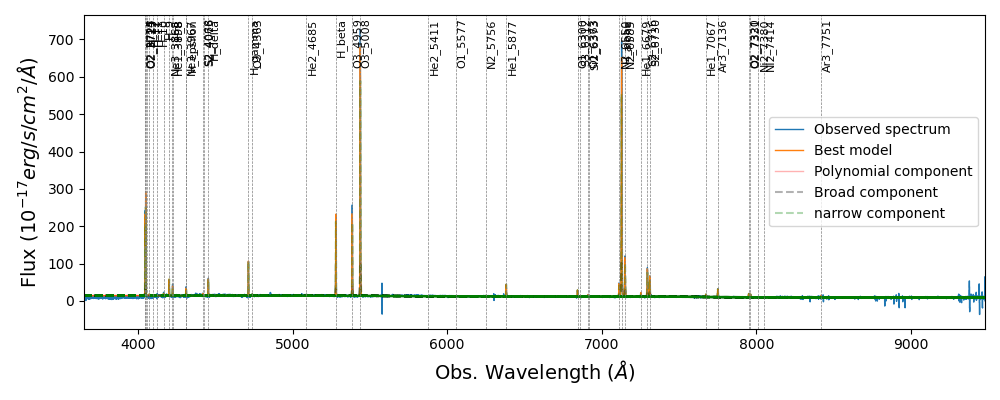

In [185]:
wave, flux, sigma = read_data(J0328)
sigmas = first_sigma_est(wave, flux, sigma,
                            J0328.linelist_dict,
                            J0328.redshift,
                            plot=True)